In [ ]:
# -*- coding: utf-8 -*-
"""semifinal.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/12zp4tqVZ-m-REQfKK2A84_-iplgMq3oq

# Model 1: Value-only     | Quarterly rebalancing | 3 portfolios
# Model 2: Momentum-only  | Weekly rebalancing    | 3 portfolios

# Portfolio construction:
    # Within each sector → sort by signal → assign top/mid/bot third
    # Combine across sectors → P1 / P2 / P3

Vietnamese Market Adaptations:
    1. Long-only (no shorting)
    2. Sector-based value: P/B for Banks/Financials, P/E for others
    3. Negative P/E excluded from ranking
    4. 45-day publication lag on quarterly data
    5. Trading fee model for weekly momentum rebalancing

Model 1: Value-only | Quarterly rebalancing | 3 portfolios
"""

In [1]:
# ── CELL 1: IMPORT LIBRARIES ──────────────────────────────────────────

import pandas as pd
import numpy as np
import re
import io
import warnings
from google.colab import files

warnings.filterwarnings("ignore")

print("✓ Libraries loaded")

✓ Libraries loaded


In [2]:
# ── CELL 2: CONFIGURATION ─────────────────────────────────────────────
# --> EDIT THIS CELL to match your data

# Price file column names
COL_DATE    = "time"
COL_TICKER  = "ticker"
COL_CLOSE   = "close"
COL_VOLUME  = "volume"
DATE_FORMAT = "%m/%d/%Y %H:%M"

# Value signal settings
FINANCIAL_SECTORS = ["Financials", "Banks"]   # use P/B for these sectors
PE_MIN            = 0
PE_MAX            = 200
PUB_LAG_DAYS      = 45                        # days after quarter end before data is published

# Momentum settings
MOM_WEEK_START    = 0     # look onto the current Thursday price
MOM_WEEK_END      = 1    # look back the last Thursday

# Portfolio settings
MIN_SECTOR_SIZE   = 6     # sectors below this → all stocks go to P2

# Trading fee settings (Vietnam market)
BUY_FEE_PCT       = 0.15  # brokerage fee on buy (%)
SELL_FEE_PCT      = 0.15  # brokerage fee on sell (%)
SELL_TAX_PCT      = 0.10  # personal income tax on sell (%)

print("✓ Configuration set")
print(f"  Financial sectors   : {FINANCIAL_SECTORS} → use 1/P/B")
print(f"  Other sectors       : use 1/P/E")
print(f"  Min sector size     : {MIN_SECTOR_SIZE} stocks")
print(f"  Round-trip cost     : {BUY_FEE_PCT + SELL_FEE_PCT + SELL_TAX_PCT:.2f}%")

✓ Configuration set
  Financial sectors   : ['Financials', 'Banks'] → use 1/P/B
  Other sectors       : use 1/P/E
  Min sector size     : 6 stocks
  Round-trip cost     : 0.40%


In [3]:
# ── CELL 3: UPLOAD PRICE FILES ────────────────────────────────────────
# Click "Choose Files" and select all CSV price files at once
print("Upload all price CSV files...")
uploaded_prices = files.upload()

print(f"\n✓ {len(uploaded_prices)} files uploaded:")
for fname in uploaded_prices:
    print(f"  {fname}")

Upload all price CSV files...


Saving vn_stocks_daily_batch2.csv to vn_stocks_daily_batch2.csv
Saving vn_stocks_daily_batch3.csv to vn_stocks_daily_batch3.csv
Saving vn_stocks_daily_batch4.csv to vn_stocks_daily_batch4.csv
Saving vn_stocks_daily_batch5.csv to vn_stocks_daily_batch5.csv
Saving vn_stocks_daily_batch6.csv to vn_stocks_daily_batch6.csv

✓ 5 files uploaded:
  vn_stocks_daily_batch2.csv
  vn_stocks_daily_batch3.csv
  vn_stocks_daily_batch4.csv
  vn_stocks_daily_batch5.csv
  vn_stocks_daily_batch6.csv


In [4]:
# ── CELL 4: UPLOAD FUNDAMENTAL DATA FILE ─────────────────────────────
# Upload the Excel file of Valuation data (P/E; P/B)
print("Upload the Excel file of Valuation data...")
uploaded_fund = files.upload()

fund_filename = list(uploaded_fund.keys())[0]
print(f"\n✓ Uploaded: {fund_filename}")

Upload the Excel file of Valuation data...


Saving FiinProX_DE_Corporate_20260424 (1).xlsx to FiinProX_DE_Corporate_20260424 (1).xlsx

✓ Uploaded: FiinProX_DE_Corporate_20260424 (1).xlsx


In [5]:
# ── CELL 5: LOAD AND COMBINE PRICE FILES ─────────────────────────────

print("=" * 60)
print("LOADING PRICE DATA")
print("=" * 60)

frames = []
for fname, content in uploaded_prices.items():
    df = pd.read_csv(io.BytesIO(content))
    print(f"  {fname}: {len(df):>10,} rows | {df[COL_TICKER].nunique():>4} stocks")
    frames.append(df)

prices_raw = pd.concat(frames, ignore_index=True)

# Standardize column names
prices_raw = prices_raw.rename(columns={
    COL_DATE   : "date",
    COL_TICKER : "ticker",
    COL_CLOSE  : "close",
    COL_VOLUME : "volume",
})

# Parse and clean
prices_raw["date"]   = pd.to_datetime(prices_raw["date"], format=DATE_FORMAT)
prices_raw["ticker"] = prices_raw["ticker"].str.strip().str.upper()
prices_raw["close"]  = pd.to_numeric(prices_raw["close"],  errors="coerce")
prices_raw["volume"] = pd.to_numeric(prices_raw["volume"], errors="coerce")

# Remove duplicates and bad prices
prices_raw = prices_raw.drop_duplicates(subset=["date", "ticker"], keep="first")
prices_raw = prices_raw[prices_raw["close"] > 0].dropna(subset=["close"])
prices_raw = prices_raw.sort_values(["ticker", "date"]).reset_index(drop=True)

print(f"\n  Combined : {len(prices_raw):,} rows | {prices_raw['ticker'].nunique()} stocks")
print(f"  Date range: {prices_raw['date'].min().date()} → {prices_raw['date'].max().date()}")
print("✓ Price data loaded")

LOADING PRICE DATA
  vn_stocks_daily_batch2.csv:    138,176 rows |   60 stocks
  vn_stocks_daily_batch3.csv:    138,450 rows |   60 stocks
  vn_stocks_daily_batch4.csv:    143,401 rows |   60 stocks
  vn_stocks_daily_batch5.csv:    141,708 rows |   61 stocks
  vn_stocks_daily_batch6.csv:    139,145 rows |   60 stocks

  Combined : 700,880 rows | 301 stocks
  Date range: 2015-09-28 → 2026-05-18
✓ Price data loaded


In [6]:
# ── CELL 6: BUILD PRICE MATRICES ─────────────────────────────────────

print("Building price matrices...")

# Wide format daily matrix
daily_wide = prices_raw.pivot(index="date", columns="ticker", values="close")

# Monthly (for reference)
monthly_prices  = daily_wide.resample("ME").last()
monthly_returns = monthly_prices.pct_change().iloc[1:]

# Weekly (for momentum model)
# FIXED — anchors to Friday (W-FRI)
weekly_prices  = daily_wide.resample("W-THU").last()
weekly_returns = weekly_prices.pct_change().iloc[1:]

print(f"  Daily  matrix : {daily_wide.shape}")
print(f"  Monthly matrix: {monthly_prices.shape}")
print(f"  Weekly  matrix: {weekly_prices.shape}")
print("✓ Price matrices built")

Building price matrices...
  Daily  matrix : (2657, 301)
  Monthly matrix: (129, 301)
  Weekly  matrix: (556, 301)
✓ Price matrices built


In [7]:
# ── CELL 7: LOAD AND PARSE FUNDAMENTAL DATA ───────────────────────────

print("Parsing fundamental data...")

df_raw = pd.read_excel(
    io.BytesIO(uploaded_fund[fund_filename]),
    sheet_name="Sheet1"
)

df_raw.columns = [str(c).replace("\n", " ").strip() for c in df_raw.columns]

SECTOR_COL = "Industrial sector (ICB) L1"

# Check required columns
required_cols = ["Ticker", SECTOR_COL]
missing_cols = [c for c in required_cols if c not in df_raw.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Identify signal columns
pe_cols = [c for c in df_raw.columns if "P/E" in c and "Quarter" in c]
pb_cols = [c for c in df_raw.columns if "P/B" in c and "Quarter" in c]

print(f"  P/E columns : {len(pe_cols)}")
print(f"  P/B columns : {len(pb_cols)}")

if len(pe_cols) == 0:
    raise ValueError("No P/E columns found. Check column names.")

if len(pb_cols) == 0:
    raise ValueError("No P/B columns found. Check column names.")

def extract_quarter(col):
    m = re.search(r"Q\d\.\d{4}", col)
    return m.group(0) if m else None

def quarter_to_safe_date(q_str, lag=PUB_LAG_DAYS):
    qe = {
        "Q1": "03-31",
        "Q2": "06-30",
        "Q3": "09-30",
        "Q4": "12-31"
    }
    q, year = q_str.split(".")
    return pd.to_datetime(f"{year}-{qe[q]}") + pd.Timedelta(days=lag)

def melt_metric(df, cols, col_label, id_cols):
    melted = df[id_cols + cols].melt(
        id_vars=id_cols,
        value_vars=cols,
        var_name="col",
        value_name=col_label
    )
    melted["quarter"] = melted["col"].apply(extract_quarter)
    melted = melted.drop(columns="col")
    melted = melted.dropna(subset=["quarter"])
    return melted

df_pe = melt_metric(df_raw, pe_cols, "pe", ["Ticker", SECTOR_COL])
df_pb = melt_metric(df_raw, pb_cols, "pb", ["Ticker"])

fund = df_pe.merge(
    df_pb,
    on=["Ticker", "quarter"],
    how="inner"
)

fund = fund.rename(columns={
    "Ticker": "ticker",
    SECTOR_COL: "sector"
})

fund["ticker"] = fund["ticker"].astype(str).str.strip().str.upper()
fund["sector"] = fund["sector"].astype(str).str.strip()

fund["pe"] = pd.to_numeric(fund["pe"], errors="coerce")
fund["pb"] = pd.to_numeric(fund["pb"], errors="coerce")

fund["safe_date"] = fund["quarter"].apply(quarter_to_safe_date)

fund = fund.sort_values(["ticker", "safe_date"]).reset_index(drop=True)

# Sector lookup: most recent sector per ticker
sector_lookup = (
    fund.sort_values("safe_date")
    .drop_duplicates("ticker", keep="last")
    .set_index("ticker")["sector"]
)

print(f"\n  Stocks     : {fund['ticker'].nunique()}")
print(f"  Quarters   : {fund['quarter'].nunique()}")
print(f"\n  Sector breakdown:")
print(fund.drop_duplicates("ticker")["sector"].value_counts().to_string())
print("✓ Fundamental data loaded")

Parsing fundamental data...
  P/E columns : 21
  P/B columns : 21

  Stocks     : 301
  Quarters   : 21

  Sector breakdown:
sector
Financials           73
Industrials          73
Consumer Goods       47
Basic Materials      37
Utilities            19
Banks                18
Consumer Services    16
Technology            8
Health Care           7
Oil & Gas             3
✓ Fundamental data loaded


In [8]:
# ── CELL 8: SHARED HELPER — WITHIN-SECTOR TERTILE SORT ───────────────

def assign_within_sector_tertiles(
    df,
    signal_col,
    sector_col,
    ticker_col       = "ticker",
    min_sector_size  = MIN_SECTOR_SIZE,
    higher_is_better = True,
):
    """
    Assigns each stock to P1, P2, or P3 based on within-sector rank.

    For each sector:
      - Top    floor(n/3) stocks → P1  (best signal)
      - Bottom floor(n/3) stocks → P3  (worst signal)
      - Remaining middle stocks  → P2  (neutral)
      - Sectors < min_sector_size → all stocks go to P2

    Parameters:
      df               : DataFrame with ticker, signal, sector columns
      signal_col       : column name of the signal to rank by
      sector_col       : column name of the sector
      min_sector_size  : minimum stocks in sector to perform split
      higher_is_better : True  → high signal = P1 (value: high 1/PE = cheap)
                         True  → high signal = P1 (momentum: high return = strong)

    Returns:
      df with added columns: portfolio, within_sector_rank, within_sector_size
    """
    result = df.copy()
    result["portfolio"]          = "P2"
    result["within_sector_rank"] = np.nan
    result["within_sector_size"] = np.nan

    for sector, group in result.groupby(sector_col):

        valid_idx = group[signal_col].dropna().index
        n         = len(valid_idx)

        result.loc[group.index, "within_sector_size"] = n

        if n < min_sector_size:
            # Too few stocks — assign all to P2 (neutral)
            continue

        # Rank within sector: rank 1 = best signal
        ranked = result.loc[valid_idx, signal_col].rank(
            ascending = not higher_is_better,
            method    = "first"
        )
        result.loc[valid_idx, "within_sector_rank"] = ranked

        # Tertile cutoffs
        n_top = int(np.floor(n / 3))    # P1 size
        n_bot = int(np.floor(n / 3))    # P3 size

        for idx, rank in ranked.items():
            if rank <= n_top:
                result.loc[idx, "portfolio"] = "P1"
            elif rank > n - n_bot:
                result.loc[idx, "portfolio"] = "P3"
            else:
                result.loc[idx, "portfolio"] = "P2"

    return result


def print_portfolio_sizes(df, date_col="date", label=""):
    """Print portfolio size summary."""
    sizes = df.groupby([date_col, "portfolio"]).size().unstack(fill_value=0)
    avg   = sizes.mean()
    print(f"\n  {label} average portfolio sizes:")
    print(f"  P1: {avg.get('P1',0):.0f} stocks  |  "
          f"P2: {avg.get('P2',0):.0f} stocks  |  "
          f"P3: {avg.get('P3',0):.0f} stocks")


print("✓ Helper function loaded")

✓ Helper function loaded


In [9]:
# ── CELL 9: BUILD VALUE PORTFOLIOS (QUARTERLY) ───────────────────────

print("Building value portfolios (quarterly, within-sector sort)...")

def safe_earnings_yield(pe):
    """1/PE for non-financials. Returns NaN for negative or extreme P/E."""
    if pd.isna(pe) or pe <= PE_MIN or pe > PE_MAX:
        return np.nan
    return 1.0 / pe

def safe_book_yield(pb):
    """1/PB for financials. Returns NaN for negative P/B."""
    if pd.isna(pb) or pb <= 0:
        return np.nan
    return 1.0 / pb

all_safe_dates      = sorted(fund["safe_date"].unique())
value_all_quarters  = []

for rebal_date in all_safe_dates:

    # Get most recently published data for each stock
    fund_avail = (
    fund[fund["safe_date"] <= rebal_date]
    .assign(
        value_signal = lambda df: df.apply(
            lambda r: safe_book_yield(r["pb"])
            if r["sector"] in FINANCIAL_SECTORS
            else safe_earnings_yield(r["pe"]),
            axis=1
        ),
        measure = lambda df: df["sector"].apply(
            lambda s: "1/P/B" if s in FINANCIAL_SECTORS else "1/P/E"
        )
    )
    .dropna(subset=["value_signal"])   # ← remove NaN BEFORE picking latest
    .sort_values("safe_date")
    .drop_duplicates(subset="ticker", keep="last")
    .copy()
)

    if len(fund_avail) < 20:
        continue

    # Compute value signal: 1/PB for financials, 1/PE for others
    fund_avail["value_signal"] = fund_avail.apply(
        lambda r: safe_book_yield(r["pb"])
        if r["sector"] in FINANCIAL_SECTORS
        else safe_earnings_yield(r["pe"]),
        axis=1
    )

    fund_avail["measure"] = fund_avail["sector"].apply(
        lambda s: "1/P/B" if s in FINANCIAL_SECTORS else "1/P/E"
    )

    # Within-sector tertile assignment
    quarter_df = assign_within_sector_tertiles(
        df               = fund_avail,
        signal_col       = "value_signal",
        sector_col       = "sector",
        ticker_col       = "ticker",
        higher_is_better = True,  # high 1/PE or 1/PB = cheap = P1
    )

    quarter_df["date"] = rebal_date

    value_all_quarters.append(
        quarter_df[[
            "ticker", "sector", "measure", "value_signal",
            "within_sector_rank", "within_sector_size",
            "portfolio", "date"
        ]]
    )

value_model = pd.concat(value_all_quarters, ignore_index=True)
value_model = value_model.sort_values(
    ["date", "portfolio", "within_sector_rank"]
).reset_index(drop=True)

print(f"\n  Quarters computed: {value_model['date'].nunique()}")
print_portfolio_sizes(value_model, label="Value model")
print("✓ Value portfolios built")

Building value portfolios (quarterly, within-sector sort)...

  Quarters computed: 21

  Value model average portfolio sizes:
  P1: 94 stocks  |  P2: 106 stocks  |  P3: 94 stocks
✓ Value portfolios built


In [10]:
# ── CELL 10: VALUE MODEL — SECTOR COMPOSITION ────────────────────────

latest_q   = value_model["date"].max()
latest_val = value_model[value_model["date"] == latest_q]

print("=" * 70)
print(f"VALUE MODEL — SECTOR COMPOSITION as of {latest_q.date()}")
print("=" * 70)

sectors    = sorted(latest_val["sector"].dropna().unique())

print(f"\n  {'Sector':<25} {'P1':>6} {'P2':>6} {'P3':>6}  {'Total':>6}  Note")
print(f"  {'─'*25} {'─'*6} {'─'*6} {'─'*6}  {'─'*6}  {'─'*15}")

for sector in sectors:
    sec_df = latest_val[latest_val["sector"] == sector]
    counts = sec_df.groupby("portfolio").size()
    p1     = counts.get("P1", 0)
    p2     = counts.get("P2", 0)
    p3     = counts.get("P3", 0)
    total  = p1 + p2 + p3
    note   = "all→P2 (small)" if total < MIN_SECTOR_SIZE else ""
    msure  = "1/P/B" if sector in FINANCIAL_SECTORS else "1/P/E"
    print(f"  {sector:<25} {p1:>6} {p2:>6} {p3:>6}  {total:>6}  {msure} {note}")

totals = latest_val.groupby("portfolio").size()
print(f"  {'─'*25} {'─'*6} {'─'*6} {'─'*6}  {'─'*6}")
print(f"  {'TOTAL':<25} "
      f"{totals.get('P1',0):>6} "
      f"{totals.get('P2',0):>6} "
      f"{totals.get('P3',0):>6}  "
      f"{totals.sum():>6}")

print(f"\n  P2 is slightly larger than P1/P3 because it absorbs")
print(f"  the remainder when sector sizes are not divisible by 3.")

# Check what quarters exist in fund DataFrame
print("Quarters in fund data:")
print(fund["quarter"].value_counts().sort_index().to_string())

latest_safe_date = fund["safe_date"].max()

latest_quarters = (
    fund.loc[fund["safe_date"] == latest_safe_date, "quarter"]
    .drop_duplicates()
    .tolist()
)

print(f"Latest safe date in fund : {latest_safe_date.date()}")
print(f"Latest quarter in fund   : {latest_quarters}")

VALUE MODEL — SECTOR COMPOSITION as of 2026-05-15

  Sector                        P1     P2     P3   Total  Note
  ───────────────────────── ────── ────── ──────  ──────  ───────────────
  Banks                          6      6      6      18  1/P/B 
  Basic Materials               12     13     12      37  1/P/E 
  Consumer Goods                15     17     15      47  1/P/E 
  Consumer Services              5      6      5      16  1/P/E 
  Financials                    24     25     24      73  1/P/B 
  Health Care                    2      3      2       7  1/P/E 
  Industrials                   24     25     24      73  1/P/E 
  Oil & Gas                      0      3      0       3  1/P/E all→P2 (small)
  Technology                     2      4      2       8  1/P/E 
  Utilities                      6      7      6      19  1/P/E 
  ───────────────────────── ────── ────── ──────  ──────
  TOTAL                         96    109     96     301

  P2 is slightly larger than P1/P

In [11]:
# ── CELL 11: VALUE MODEL — PREVIEW EACH PORTFOLIO ────────────────────

for pf, label in [
    ("P1", "CHEAP      — top third by value within each sector"),
    ("P2", "MIDDLE     — mid third by value within each sector"),
    ("P3", "EXPENSIVE  — bottom third by value within each sector"),
]:
    pf_df = latest_val[latest_val["portfolio"] == pf].sort_values(
        ["sector", "within_sector_rank"]
    )

    print(f"\n{'─'*70}")
    print(f"  {pf}: {label} | {len(pf_df)} stocks")
    print(f"{'─'*70}")
    print(f"  {'Ticker':<8} {'Sector':<22} {'Measure':<7} "
          f"{'Signal':>8} {'WS Rank':>8} {'WS Size':>8}")
    print(f"  {'─'*8} {'─'*22} {'─'*7} {'─'*8} {'─'*8} {'─'*8}")

    for _, r in pf_df.head(15).iterrows():
        print(
            f"  {r['ticker']:<8} "
            f"{str(r['sector']):<22} "
            f"{r['measure']:<7} "
            f"{r['value_signal']:>8.4f} "
            f"{int(r['within_sector_rank']):>8} "
            f"{int(r['within_sector_size']):>8}"
        )
    if len(pf_df) > 15:
        print(f"  ... and {len(pf_df)-15} more stocks")


──────────────────────────────────────────────────────────────────────
  P1: CHEAP      — top third by value within each sector | 96 stocks
──────────────────────────────────────────────────────────────────────
  Ticker   Sector                 Measure   Signal  WS Rank  WS Size
  ──────── ────────────────────── ─────── ──────── ──────── ────────
  OCB      Banks                  1/P/B     1.1628        1       18
  MSB      Banks                  1/P/B     1.0417        2       18
  TPB      Banks                  1/P/B     1.0000        3       18
  NAB      Banks                  1/P/B     0.9709        4       18
  SHB      Banks                  1/P/B     0.9615        5       18
  VIB      Banks                  1/P/B     0.9009        6       18
  HII      Basic Materials        1/P/E     0.2732        1       37
  TNI      Basic Materials        1/P/E     0.2203        2       37
  VPG      Basic Materials        1/P/E     0.2049        3       37
  AAA      Basic Materials   

In [12]:
# ── CELL 12: VALUE MODEL — TURNOVER AND SAVE ─────────────────────────

# Quarterly turnover by portfolio
print("Value Model — Quarterly Turnover:")
for pf in ["P1", "P2", "P3"]:
    holdings_by_q = (
        value_model[value_model["portfolio"] == pf]
        .groupby("date")["ticker"]
        .apply(set)
    )
    if len(holdings_by_q) > 1:
        dates     = sorted(holdings_by_q.index)
        turnovers = [
            len(holdings_by_q[dates[i-1]].symmetric_difference(
                holdings_by_q[dates[i]]
            )) / max(len(holdings_by_q[dates[i-1]].union(
                holdings_by_q[dates[i]]
            )), 1)
            for i in range(1, len(dates))
        ]
        print(f"  {pf}: mean={np.mean(turnovers):.1%}  "
              f"min={np.min(turnovers):.1%}  "
              f"max={np.max(turnovers):.1%}")

# Save and download
print("\nSaving value model files...")
value_model.to_csv("value_model_3portfolios.csv", index=False)
files.download("value_model_3portfolios.csv")

for pf in ["P1", "P2", "P3"]:
    fname = f"value_model_{pf.lower()}.csv"
    value_model[value_model["portfolio"] == pf].to_csv(fname, index=False)
    files.download(fname)

print("✓ Value model files downloaded")

Value Model — Quarterly Turnover:
  P1: mean=32.7%  min=19.8%  max=50.8%
  P2: mean=45.2%  min=29.7%  max=58.0%
  P3: mean=31.3%  min=15.4%  max=40.7%

Saving value model files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Value model files downloaded


In [13]:
# CELL 13: UPLOAD THE MARKET CAPITALIZATION DATASET
from google.colab import files
import io

print("Upload your market cap file (CSV or Excel)...")
uploaded_mcap = files.upload()

mcap_filename = list(uploaded_mcap.keys())[0]
print(f"\n✓ Uploaded: {mcap_filename}")

Upload your market cap file (CSV or Excel)...


Saving FiinProX_DE_Du_lieu_giao_dich_Doanh_nghiep_Theo_ngay_20260513 (1).xlsx to FiinProX_DE_Du_lieu_giao_dich_Doanh_nghiep_Theo_ngay_20260513 (1).xlsx
Saving FiinProX_DE_Du_lieu_giao_dich_Doanh_nghiep_Theo_ngay_20260513 (2).xlsx to FiinProX_DE_Du_lieu_giao_dich_Doanh_nghiep_Theo_ngay_20260513 (2).xlsx
Saving FiinProX_DE_Du_lieu_giao_dich_Doanh_nghiep_Theo_ngay_20260513.xlsx to FiinProX_DE_Du_lieu_giao_dich_Doanh_nghiep_Theo_ngay_20260513.xlsx

✓ Uploaded: FiinProX_DE_Du_lieu_giao_dich_Doanh_nghiep_Theo_ngay_20260513 (1).xlsx


In [14]:
# CELL 14: RENAME COLUMNS
# Column names in your market cap file
MCAP_COL_TICKER = "ticker"
MCAP_COL_DATE   = "Date"
MCAP_COL_MCAP   = "Market cap"

# Date format in your file
# Your sample shows "05/12/2026" — this is ambiguous, choose one:
#   "%d/%m/%Y" → December 5, 2026  (Vietnamese standard)
#   "%m/%d/%Y" → May 12, 2026      (US standard)
MCAP_DATE_FORMAT = "%m/%d/%Y"

print("Configuration:")
print(f"  Ticker column : '{MCAP_COL_TICKER}'")
print(f"  Date column   : '{MCAP_COL_DATE}'")
print(f"  Market cap col: '{MCAP_COL_MCAP}'")
print(f"  Date format   : {MCAP_DATE_FORMAT}")

Configuration:
  Ticker column : 'ticker'
  Date column   : 'Date'
  Market cap col: 'Market cap'
  Date format   : %m/%d/%Y


In [15]:
# CELL 15: PARSE ALL MARKET CAP FILES

import pandas as pd
import numpy as np
import io

print("Parsing all uploaded market cap files...")
print("=" * 60)

all_mcap_frames = []

for fname, content in uploaded_mcap.items():
    # Read CSV or Excel automatically
    if fname.endswith(".xlsx") or fname.endswith(".xls"):
        df = pd.read_excel(io.BytesIO(content))
    else:
        df = pd.read_csv(io.BytesIO(content))

    print(f"\n  File: {fname}")
    print(f"    Raw shape : {df.shape}")
    print(f"    Columns   : {list(df.columns)}")
    print(f"    Unique tickers: {df[MCAP_COL_TICKER].nunique()}")

    all_mcap_frames.append(df)

# Combine all 3 files
mcap_raw = pd.concat(all_mcap_frames, ignore_index=True)

# Rename and clean
mcap_raw = mcap_raw.rename(columns={
    MCAP_COL_TICKER : "ticker",
    MCAP_COL_DATE   : "date",
    MCAP_COL_MCAP   : "mcap",
})

mcap_raw["ticker"] = mcap_raw["ticker"].astype(str).str.strip().str.upper()
mcap_raw["date"]   = pd.to_datetime(mcap_raw["date"], format=MCAP_DATE_FORMAT)
mcap_raw["mcap"]   = pd.to_numeric(mcap_raw["mcap"], errors="coerce")

# Remove duplicates (same ticker + date appearing in multiple files)
mcap_raw = mcap_raw.drop_duplicates(subset=["ticker", "date"], keep="first")

# Drop missing values
mcap_raw = mcap_raw.dropna(subset=["mcap"])
mcap_raw = mcap_raw[mcap_raw["mcap"] > 0]
mcap_raw = mcap_raw.sort_values(["ticker", "date"]).reset_index(drop=True)

print(f"\n" + "=" * 60)
print(f"  Combined rows   : {len(mcap_raw):,}")
print(f"  Unique tickers  : {mcap_raw['ticker'].nunique()}")
print(f"  Date range      : {mcap_raw['date'].min().date()} → {mcap_raw['date'].max().date()}")
print("✓ All market cap files combined")

Parsing all uploaded market cap files...

  File: FiinProX_DE_Du_lieu_giao_dich_Doanh_nghiep_Theo_ngay_20260513 (1).xlsx
    Raw shape : (130710, 3)
    Columns   : ['ticker', 'Date', 'Market cap']
    Unique tickers: 100

  File: FiinProX_DE_Du_lieu_giao_dich_Doanh_nghiep_Theo_ngay_20260513 (2).xlsx
    Raw shape : (130031, 3)
    Columns   : ['ticker', 'Date', 'Market cap']
    Unique tickers: 101

  File: FiinProX_DE_Du_lieu_giao_dich_Doanh_nghiep_Theo_ngay_20260513.xlsx
    Raw shape : (129163, 3)
    Columns   : ['ticker', 'Date', 'Market cap']
    Unique tickers: 100

  Combined rows   : 388,717
  Unique tickers  : 301
  Date range      : 2021-02-01 → 2026-05-12
✓ All market cap files combined


In [16]:
# CELL 16: BUILD MARKET CAP MATRIX

print("Building market cap matrix...")

# Pivot raw data: rows=date, cols=ticker, values=mcap
mcap_daily = mcap_raw.pivot_table(
    index   = "date",
    columns = "ticker",
    values  = "mcap",
    aggfunc = "last"   # if duplicates, take last
)

# Get weekly dates from price data
week_dates = weekly_prices.index

# Build weekly mcap matrix by forward-filling
# For each weekly date, find most recent mcap on or before that date
mcap_weekly = pd.DataFrame(
    np.nan,
    index   = week_dates,
    columns = mcap_daily.columns
)

# Reindex mcap_daily to include all weekly dates, then forward-fill
all_dates    = sorted(set(mcap_daily.index) | set(week_dates))
mcap_aligned = mcap_daily.reindex(all_dates).ffill()
mcap_weekly  = mcap_aligned.loc[week_dates]

# Coverage check
latest_coverage = mcap_weekly.iloc[-1].notna().sum()
first_valid     = mcap_weekly.notna().any(axis=1).idxmax()
total_cells     = mcap_weekly.shape[0] * mcap_weekly.shape[1]
missing_pct     = mcap_weekly.isna().mean().mean()

print(f"  Weekly mcap matrix shape  : {mcap_weekly.shape}")
print(f"  First week with data      : {first_valid.date()}")
print(f"  Latest week coverage      : {latest_coverage} stocks")
print(f"  Missing cells             : {missing_pct:.1%}")
print("✓ Weekly market cap matrix built")

Building market cap matrix...
  Weekly mcap matrix shape  : (556, 301)
  First week with data      : 2021-02-04
  Latest week coverage      : 301 stocks
  Missing cells             : 50.9%
✓ Weekly market cap matrix built


In [17]:
# CELL 17: VALUE MODEL - QUARTERLY REBALANCING WITH MARKET CAP WEIGHTING
print("VALUE MODEL — QUARTERLY REBALANCING WITH MARKET CAP WEIGHTS")

# Choose which portfolios to build
VALUE_PORTFOLIOS = ["P1", "P2", "P3"]

# Copy and clean value model
value_model_q = value_model.copy()
value_model_q["date"] = pd.to_datetime(value_model_q["date"])
value_model_q["ticker"] = value_model_q["ticker"].astype(str).str.strip().str.upper()

# Quarterly rebalance dates come directly from value_model
quarter_dates = pd.DatetimeIndex(
    sorted(value_model_q["date"].dropna().unique())
)

print(f"Quarterly rebalance dates: {len(quarter_dates)}")
print(f"Date range: {quarter_dates.min().date()} → {quarter_dates.max().date()}")

# Build market-cap matrix

mcap_clean = mcap_raw.copy()
mcap_clean["date"] = pd.to_datetime(mcap_clean["date"])
mcap_clean["ticker"] = mcap_clean["ticker"].astype(str).str.strip().str.upper()
mcap_clean["mcap"] = pd.to_numeric(mcap_clean["mcap"], errors="coerce")

mcap_clean = (
    mcap_clean
    .dropna(subset=["date", "ticker", "mcap"])
    .query("mcap > 0")
    .sort_values(["ticker", "date"])
)

mcap_wide = (
    mcap_clean
    .pivot_table(
        index="date",
        columns="ticker",
        values="mcap",
        aggfunc="last"
    )
    .sort_index()
)

# Latest available market cap on or before each quarterly rebalance date
mcap_at_rebal = mcap_wide.reindex(quarter_dates, method="ffill")

# Build price matrix at quarterly rebalance dates

daily_wide_q = daily_wide.copy()
daily_wide_q.index = pd.to_datetime(daily_wide_q.index)
daily_wide_q = daily_wide_q.sort_index()

# Latest available price on or before each rebalance date
price_at_rebal = daily_wide_q.reindex(quarter_dates, method="ffill")


def get_period_returns(start_date, end_date):
    """
    Return from start_date to end_date using prices available
    on or before each date.
    """
    start_px = price_at_rebal.loc[start_date]
    end_px   = price_at_rebal.loc[end_date]

    ret = end_px / start_px - 1
    ret = ret.replace([np.inf, -np.inf], np.nan)

    return ret


def compute_sector_replicated_mcap_weights(assigned_df, portfolio_name):
    """
    Compute market-cap weights for one value portfolio.

    Weighting method:
      1. Compute sector weights from the full eligible universe.
      2. Keep only sectors represented in the target portfolio.
      3. Redistribute unavailable sector weights across represented sectors.
      4. Within each represented sector, weight stocks by market cap.

    """

    eligible = assigned_df.copy()

    eligible = eligible.dropna(subset=["ticker", "sector", "mcap"])
    eligible = eligible[eligible["mcap"] > 0]

    pf_df = eligible[eligible["portfolio"] == portfolio_name].copy()

    if pf_df.empty:
        return pf_df

    # Sector weights from full eligible universe
    universe_sector_mcap = eligible.groupby("sector")["mcap"].sum()
    universe_total_mcap  = universe_sector_mcap.sum()

    if universe_total_mcap <= 0:
        return pd.DataFrame()

    sector_weight_universe = universe_sector_mcap / universe_total_mcap

    # Market cap inside this portfolio by sector
    pf_sector_mcap = pf_df.groupby("sector")["mcap"].sum()

    represented_sectors = pf_sector_mcap[pf_sector_mcap > 0].index

    sector_weight_target = sector_weight_universe.reindex(
        represented_sectors
    ).fillna(0)

    if sector_weight_target.sum() <= 0:
        return pd.DataFrame()

    # Redistribute weights only across sectors represented in this portfolio
    sector_weight_target = sector_weight_target / sector_weight_target.sum()

    pf_df["sector_weight_target"] = pf_df["sector"].map(sector_weight_target)
    pf_df["portfolio_sector_mcap"] = pf_df["sector"].map(pf_sector_mcap)

    pf_df["weight_within_sector"] = (
        pf_df["mcap"] / pf_df["portfolio_sector_mcap"]
    )

    pf_df["weight"] = (
        pf_df["sector_weight_target"] *
        pf_df["weight_within_sector"]
    )

    pf_df["weight"] = (
        pf_df["weight"]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    if pf_df["weight"].sum() > 0:
        pf_df["weight"] = pf_df["weight"] / pf_df["weight"].sum()
    else:
        return pd.DataFrame()

    return pf_df


# Quarterly rebalance loop

all_quarter_rows = []
all_stock_rows   = []

prev_weights_by_pf = {pf: {} for pf in VALUE_PORTFOLIOS}
prev_date_by_pf    = {pf: None for pf in VALUE_PORTFOLIOS}

for i, date in enumerate(quarter_dates):

    # Current value-model assignments
    quarter_df = value_model_q[value_model_q["date"] == date].copy()

    if quarter_df.empty:
        continue

    # Attach market cap available at construction date
    if date not in mcap_at_rebal.index:
        continue

    mcap_row = mcap_at_rebal.loc[date]

    quarter_df["mcap"] = quarter_df["ticker"].apply(
        lambda t: mcap_row.get(t, np.nan)
    )

    quarter_df = quarter_df.dropna(subset=["mcap"])
    quarter_df = quarter_df[quarter_df["mcap"] > 0].copy()

    if len(quarter_df) < 20:
        continue

    # Next quarter return period
    if i < len(quarter_dates) - 1:
        next_date = quarter_dates[i + 1]
        ret_current_to_next = get_period_returns(date, next_date)
    else:
        next_date = pd.NaT
        ret_current_to_next = None

    for pf in VALUE_PORTFOLIOS:

        pf_df = compute_sector_replicated_mcap_weights(
            assigned_df=quarter_df,
            portfolio_name=pf
        )

        if pf_df.empty:
            continue

        curr_weights = dict(zip(pf_df["ticker"], pf_df["weight"]))
        curr_tickers = set(curr_weights.keys())

        prev_weights = prev_weights_by_pf.get(pf, {})
        prev_tickers = set(prev_weights.keys())
        prev_date    = prev_date_by_pf.get(pf)

        total_mcap = pf_df["mcap"].sum()

        # ── Fee and turnover calculation ─────────────────────────────

        if prev_date is not None and len(prev_weights) > 0:

            entering = curr_tickers - prev_tickers
            exiting  = prev_tickers - curr_tickers
            holding  = curr_tickers & prev_tickers

            # Drift previous weights from previous rebalance date to current date
            ret_prev_to_current = get_period_returns(prev_date, date)

            drifted_values = {}

            for t, prev_w in prev_weights.items():
                r = ret_prev_to_current.get(t, 0.0)

                if pd.isna(r):
                    r = 0.0

                drifted_values[t] = prev_w * (1.0 + r)

            total_drifted_value = sum(drifted_values.values())

            if total_drifted_value > 0:
                drifted_weights = {
                    t: v / total_drifted_value
                    for t, v in drifted_values.items()
                }
            else:
                drifted_weights = {
                    t: 0.0
                    for t in prev_weights.keys()
                }

            # Buy cost for entering stocks
            buy_cost = sum(
                curr_weights[t] * (BUY_FEE_PCT / 100)
                for t in entering
            )

            # Sell cost for exiting stocks
            sell_cost = sum(
                drifted_weights.get(t, 0.0) *
                ((SELL_FEE_PCT + SELL_TAX_PCT) / 100)
                for t in exiting
            )

            # Rebalance cost for existing holdings
            rebal_cost = 0.0

            for t in holding:
                target_w  = curr_weights.get(t, 0.0)
                drifted_w = drifted_weights.get(t, 0.0)

                active_trade_w = target_w - drifted_w

                if active_trade_w > 0:
                    rebal_cost += active_trade_w * (BUY_FEE_PCT / 100)

                elif active_trade_w < 0:
                    rebal_cost += abs(active_trade_w) * (
                        (SELL_FEE_PCT + SELL_TAX_PCT) / 100
                    )

            fee_drag = buy_cost + sell_cost + rebal_cost

            # Turnover based on active traded weight
            entering_turnover = sum(
                curr_weights[t]
                for t in entering
            )

            exiting_turnover = sum(
                drifted_weights.get(t, 0.0)
                for t in exiting
            )

            holding_turnover = 0.0

            for t in holding:
                target_w  = curr_weights.get(t, 0.0)
                drifted_w = drifted_weights.get(t, 0.0)

                holding_turnover += abs(target_w - drifted_w)

            turnover = (
                entering_turnover +
                exiting_turnover +
                holding_turnover
            ) / 2

        else:
            # First rebalance: buy the whole portfolio
            entering = curr_tickers
            exiting  = set()

            buy_cost = sum(
                curr_weights[t] * (BUY_FEE_PCT / 100)
                for t in curr_tickers
            )

            sell_cost  = 0.0
            rebal_cost = 0.0
            fee_drag   = buy_cost
            turnover   = 1.0

        # ── Quarterly return from current rebalance date to next date ─

        if ret_current_to_next is not None:
            weighted_ret = 0.0
            used_weight  = 0.0

            for ticker, weight in curr_weights.items():
                r = ret_current_to_next.get(ticker, np.nan)

                if not pd.isna(r):
                    weighted_ret += weight * r
                    used_weight  += weight

            gross_ret = weighted_ret / used_weight if used_weight > 0 else np.nan
            net_ret   = gross_ret - fee_drag if not pd.isna(gross_ret) else np.nan

        else:
            gross_ret = np.nan
            net_ret   = np.nan

        # ── Save quarterly portfolio summary ─────────────────────────

        all_quarter_rows.append({
            "date"       : date,
            "period_end" : next_date,
            "portfolio"  : pf,
            "n_stocks"   : len(curr_tickers),
            "n_entering" : len(entering),
            "n_exiting"  : len(exiting),
            "turnover"   : turnover,
            "buy_cost"   : buy_cost,
            "sell_cost"  : sell_cost,
            "rebal_cost" : rebal_cost,
            "fee_drag"   : fee_drag,
            "gross_ret"  : gross_ret,
            "net_ret"    : net_ret,
            "total_mcap" : total_mcap,
        })

        # ── Save stock-level weights ─────────────────────────────────

        pf_df["date"]       = date
        pf_df["period_end"] = next_date

        pf_df["status"] = pf_df["ticker"].apply(
            lambda t: "NEW" if t in entering else "HOLD"
        )

        all_stock_rows.append(
            pf_df[[
                "date", "period_end",
                "ticker", "sector", "measure",
                "portfolio", "value_signal",
                "within_sector_rank", "within_sector_size",
                "mcap", "sector_weight_target",
                "weight_within_sector", "weight",
                "status"
            ]]
        )

        # Update previous weights for this portfolio
        prev_weights_by_pf[pf] = curr_weights
        prev_date_by_pf[pf]    = date


# Build final output DataFrames

value_quarterly_results = pd.DataFrame(all_quarter_rows)

value_quarterly_stock_assign = pd.concat(
    all_stock_rows,
    ignore_index=True
)

value_quarterly_stock_assign = value_quarterly_stock_assign.sort_values(
    ["date", "portfolio", "weight"],
    ascending=[True, True, False]
).reset_index(drop=True)

print("\n✓ Quarterly value-model market-cap-weighted portfolios built")

print(f"\nQuarters computed: {value_quarterly_results['date'].nunique()}")

print("\nAverage portfolio size:")
print(
    value_quarterly_results
    .groupby("portfolio")["n_stocks"]
    .mean()
    .round(1)
    .to_string()
)

print("\nAverage quarterly turnover:")
print(
    value_quarterly_results
    .groupby("portfolio")["turnover"]
    .mean()
    .map(lambda x: f"{x:.1%}")
    .to_string()
)

print("\nAnnualized fee drag:")
print(
    value_quarterly_results
    .groupby("portfolio")["fee_drag"]
    .mean()
    .mul(4)
    .map(lambda x: f"{x:.2%}")
    .to_string()
)

print("\nAnnualized gross return:")
print(
    value_quarterly_results
    .groupby("portfolio")["gross_ret"]
    .mean()
    .mul(4)
    .map(lambda x: f"{x:.2%}")
    .to_string()
)

print("\nAnnualized net return:")
print(
    value_quarterly_results
    .groupby("portfolio")["net_ret"]
    .mean()
    .mul(4)
    .map(lambda x: f"{x:.2%}")
    .to_string()
)

VALUE MODEL — QUARTERLY REBALANCING WITH MARKET CAP WEIGHTS
Quarterly rebalance dates: 21
Date range: 2021-05-15 → 2026-05-15

✓ Quarterly value-model market-cap-weighted portfolios built

Quarters computed: 21

Average portfolio size:
portfolio
P1     93.8
P2    106.0
P3     94.0

Average quarterly turnover:
portfolio
P1    35.0%
P2    35.6%
P3    20.4%

Annualized fee drag:
portfolio
P1    0.51%
P2    0.52%
P3    0.28%

Annualized gross return:
portfolio
P1     2.83%
P2    10.16%
P3    18.38%

Annualized net return:
portfolio
P1     2.31%
P2     9.63%
P3    18.09%


In [18]:
# CELL 18: VALUE MODEL — LATEST QUARTER PORTFOLIO WITH WEIGHTs

latest_q = value_quarterly_stock_assign["date"].max()
latest_value_q = value_quarterly_stock_assign[
    value_quarterly_stock_assign["date"] == latest_q
]

def fmt_rank(x):
    """Safely format within-sector rank."""
    if pd.isna(x):
        return "-"
    return str(int(x))

def fmt_float(x, decimals=4):
    """Safely format float values."""
    if pd.isna(x):
        return "-"
    return f"{x:.{decimals}f}"

print("=" * 85)
print(f"VALUE MODEL — MARKET-CAP-WEIGHTED PORTFOLIOS as of {latest_q.date()}")
print("=" * 85)

for pf, label in [
    ("P1", "CHEAP"),
    ("P2", "MIDDLE"),
    ("P3", "EXPENSIVE"),
]:
    pf_df = latest_value_q[
        latest_value_q["portfolio"] == pf
    ].sort_values("weight", ascending=False)

    print(f"\n{'─' * 85}")
    print(f"{pf}: {label} | {len(pf_df)} stocks")
    print(f"{'─' * 85}")

    print(
        f"{'Ticker':<8} "
        f"{'Sector':<24} "
        f"{'Measure':<8} "
        f"{'Weight':>8} "
        f"{'Mcap (B)':>12} "
        f"{'Value Sig':>10} "
        f"{'Rank':>6} "
        f"{'Status':<6}"
    )

    print(
        f"{'─'*8} "
        f"{'─'*24} "
        f"{'─'*8} "
        f"{'─'*8} "
        f"{'─'*12} "
        f"{'─'*10} "
        f"{'─'*6} "
        f"{'─'*6}"
    )

    for _, r in pf_df.head(20).iterrows():
        print(
            f"{r['ticker']:<8} "
            f"{str(r['sector']):<24} "
            f"{str(r['measure']):<8} "
            f"{r['weight']:>7.2%} "
            f"{r['mcap']/1e9:>11.0f} "
            f"{fmt_float(r['value_signal'], 4):>10} "
            f"{fmt_rank(r['within_sector_rank']):>6} "
            f"{str(r['status']):<6}"
        )

    if len(pf_df) > 20:
        print(f"... and {len(pf_df) - 20} more stocks")

    print(f"\nTotal weight      : {pf_df['weight'].sum():.2%}")
    print(f"Total market cap  : {pf_df['mcap'].sum()/1e12:.2f} trillion VND")
    print(f"Top 5 weight      : {pf_df['weight'].head(5).sum():.1%}")
    print(f"Top 10 weight     : {pf_df['weight'].head(10).sum():.1%}")

VALUE MODEL — MARKET-CAP-WEIGHTED PORTFOLIOS as of 2026-05-15

─────────────────────────────────────────────────────────────────────────────────────
P1: CHEAP | 96 stocks
─────────────────────────────────────────────────────────────────────────────────────
Ticker   Sector                   Measure    Weight     Mcap (B)  Value Sig   Rank Status
──────── ──────────────────────── ──────── ──────── ──────────── ────────── ────── ──────
SHB      Banks                    1/P/B      9.09%       73543     0.9615      5 HOLD  
VIB      Banks                    1/P/B      6.73%       54464     0.9009      6 NEW   
DXS      Financials               1/P/B      5.88%        4749     1.4706     21 HOLD  
TPB      Banks                    1/P/B      5.42%       43830     1.0000      3 HOLD  
MSB      Banks                    1/P/B      5.17%       41808     1.0417      2 HOLD  
CRE      Financials               1/P/B      4.36%        3524     1.6393     17 HOLD  
OCB      Banks                    1

In [19]:
# CELL 19: SAVE VALUE MODEL QUARTERLY MARKET-CAP-WEIGHTED OUTPUTS

print("Saving quarterly value-model market-cap-weighted files...")

value_quarterly_results.to_csv(
    "value_model_quarterly_market_cap_weighted_results.csv",
    index=False
)

value_quarterly_stock_assign.to_csv(
    "value_model_quarterly_market_cap_weighted_stock_assignments.csv",
    index=False
)

files.download("value_model_quarterly_market_cap_weighted_results.csv")
files.download("value_model_quarterly_market_cap_weighted_stock_assignments.csv")

for pf in ["P1", "P2", "P3"]:
    fname = f"value_model_quarterly_market_cap_weighted_{pf.lower()}.csv"

    value_quarterly_stock_assign[
        value_quarterly_stock_assign["portfolio"] == pf
    ].to_csv(fname, index=False)

    files.download(fname)

print("✓ Quarterly value-model market-cap-weighted files downloaded")

Saving quarterly value-model market-cap-weighted files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Quarterly value-model market-cap-weighted files downloaded


In [ ]:
"""Model 2: Momentum-only | Weekly rebalancing | 3 portfolios"""

In [20]:
# CELL 1: BUILD WEEKLY MOMENTUM SIGNAL

print("Computing weekly momentum signal...")

def compute_weekly_momentum(price_df, start_lag, end_lag):
    """
    Cumulative return from (t - end_lag) to (t - start_lag) weeks.
    skip last start_lag weeks to avoid short-term reversal.
    """
    result = pd.DataFrame(
        index   = price_df.index,
        columns = price_df.columns,
        dtype   = float
    )
    for t in range(end_lag, len(price_df)):
        p_start        = price_df.iloc[t - end_lag]
        p_end          = price_df.iloc[t - start_lag]
        result.iloc[t] = (p_end / p_start) - 1
    return result

weekly_mom = compute_weekly_momentum(
    weekly_prices, MOM_WEEK_START, MOM_WEEK_END
)

# Live sector assignment per ticker (re-read each period)
sector_live = (
    fund.sort_values("safe_date")
    .drop_duplicates("ticker", keep="last")
    .set_index("ticker")["sector"]
)

print(f"  Weekly price matrix : {weekly_prices.shape}")
print(f"  Latest week stocks  : {weekly_mom.iloc[-1].notna().sum()}")
print("✓ Weekly momentum built")

Computing weekly momentum signal...
  Weekly price matrix : (556, 301)
  Latest week stocks  : 298
✓ Weekly momentum built


In [21]:
# CELL 2: WEEKLY REBALANCING — 3 PORTFOLIOS
# Corrected timing:
#   Signal window      : previous Thursday close → current Thursday close
#   Rebalance action   : Friday after current Thursday close
#   Performance window : current Thursday close → next Thursday close

print("Running corrected weekly momentum rebalancing...")

week_dates      = weekly_mom.index
all_week_rows   = []      # portfolio-level summary (fees, returns)
all_stock_rows  = []      # stock-level assignments (ticker per portfolio)

for i, date in enumerate(week_dates):

    # Next weekly date for forward performance measurement
    if i < len(week_dates) - 1:
        next_date = week_dates[i + 1]
        start_px = weekly_prices.loc[date]
        end_px   = weekly_prices.loc[next_date]
        week_ret = (end_px / start_px - 1).replace([np.inf, -np.inf], np.nan)
    else:
        next_date = pd.NaT
        week_ret  = pd.Series(dtype=float)

    mom_row = weekly_mom.loc[date].dropna()
    if len(mom_row) < 20:
        continue

    # Build weekly universe DataFrame
    week_df = pd.DataFrame({
        "ticker"     : mom_row.index,
        "mom_signal" : mom_row.values,
        "sector"     : [sector_live.get(t, "Unknown") for t in mom_row.index],
    })

    # Within-sector tertile assignment
    assigned = assign_within_sector_tertiles(
        df               = week_df,
        signal_col       = "mom_signal",
        sector_col       = "sector",
        ticker_col       = "ticker",
        higher_is_better = True,
    )

    # Save individual stock assignments
    assigned["date"]       = date
    assigned["period_end"] = next_date

    all_stock_rows.append(
        assigned[[
            "ticker", "sector", "mom_signal",
            "within_sector_rank", "within_sector_size",
            "portfolio", "date", "period_end"
        ]]
    )

    # Compute count-based turnover and fee drag for this simple version
    if i > 0:
        prev_date = week_dates[i - 1]
        prev_row  = weekly_mom.loc[prev_date].dropna()

        if len(prev_row) >= 20:
            prev_df = pd.DataFrame({
                "ticker"     : prev_row.index,
                "mom_signal" : prev_row.values,
                "sector"     : [
                    sector_live.get(t, "Unknown")
                    for t in prev_row.index
                ],
            })

            prev_assigned = assign_within_sector_tertiles(
                df               = prev_df,
                signal_col       = "mom_signal",
                sector_col       = "sector",
                ticker_col       = "ticker",
                higher_is_better = True,
            ).set_index("ticker")["portfolio"]

            curr_assigned = assigned.set_index("ticker")["portfolio"]
            common        = prev_assigned.index.intersection(curr_assigned.index)
            n_changed     = (prev_assigned[common] != curr_assigned[common]).sum()
            n_total       = max(len(curr_assigned), 1)

            turnover = n_changed / n_total
            fee_drag = (
                (n_changed / n_total) *
                (BUY_FEE_PCT + SELL_FEE_PCT + SELL_TAX_PCT) / 100
            )
        else:
            turnover = 0.0
            fee_drag = 0.0
    else:
        turnover = 1.0
        fee_drag = BUY_FEE_PCT / 100

    # Compute forward returns from current Thursday to next Thursday
    for pf in ["P1", "P2", "P3"]:
        pf_tickers = assigned[assigned["portfolio"] == pf]["ticker"].tolist()

        pf_rets = [
            week_ret.get(t, np.nan)
            for t in pf_tickers
            if t in week_ret.index and not np.isnan(week_ret[t])
        ]

        gross_ret = np.mean(pf_rets) if pf_rets else np.nan
        net_ret   = gross_ret - fee_drag if not pd.isna(gross_ret) else np.nan

        all_week_rows.append({
            "date"       : date,
            "period_end" : next_date,
            "portfolio"  : pf,
            "n_stocks"   : len(pf_tickers),
            "turnover"   : turnover,
            "fee_drag"   : fee_drag,
            "gross_ret"  : gross_ret,
            "net_ret"    : net_ret,
        })


# Build both DataFrames
mom_results = pd.DataFrame(all_week_rows)

mom_stock_assign = pd.concat(
    all_stock_rows,
    ignore_index=True
)

mom_stock_assign = mom_stock_assign.sort_values(
    ["date", "portfolio", "within_sector_rank"]
).reset_index(drop=True)

print(f"\n  Weeks computed: {mom_results['date'].nunique()}")
print(f"\n  {'Portfolio':<12} {'Avg Size':>9} {'Avg Turn':>10} "
      f"{'Ann Fee':>9} {'Ann Gross':>11} {'Ann Net':>10}")
print(f"  {'─'*12} {'─'*9} {'─'*10} {'─'*9} {'─'*11} {'─'*10}")

for pf in ["P1", "P2", "P3"]:
    pf_df = mom_results[mom_results["portfolio"] == pf]
    print(
        f"  {pf:<12} "
        f"{pf_df['n_stocks'].mean():>9.0f} "
        f"{pf_df['turnover'].mean():>9.1%} "
        f"{pf_df['fee_drag'].mean()*52:>8.2%} "
        f"{pf_df['gross_ret'].mean()*52:>10.2%} "
        f"{pf_df['net_ret'].mean()*52:>9.2%}"
    )
print("✓ Corrected momentum portfolios built")

Running corrected weekly momentum rebalancing...

  Weeks computed: 553

  Portfolio     Avg Size   Avg Turn   Ann Fee   Ann Gross    Ann Net
  ──────────── ───────── ────────── ───────── ─────────── ──────────
  P1                  86     64.3%   13.38%     15.10%     1.72%
  P2                  98     64.3%   13.38%     16.16%     2.78%
  P3                  86     64.3%   13.38%     22.46%     9.08%
✓ Corrected momentum portfolios built


In [22]:
# CELL 3: MOMENTUM MODEL — LATEST WEEK HOLDINGS

latest_week = weekly_mom.index[-1]
mom_latest  = weekly_mom.loc[latest_week].dropna()

latest_week_df = pd.DataFrame({
    "ticker"     : mom_latest.index,
    "mom_signal" : mom_latest.values,
    "sector"     : [sector_live.get(t, "Unknown") for t in mom_latest.index],
})

latest_assigned = assign_within_sector_tertiles(
    df               = latest_week_df,
    signal_col       = "mom_signal",
    sector_col       = "sector",
    ticker_col       = "ticker",
    higher_is_better = True,
)

print(f"MOMENTUM MODEL — HOLDINGS as of {latest_week.date()}")

for pf, label in [
    ("P1", "STRONG MOMENTUM — top third within each sector"),
    ("P2", "MIDDLE         — mid third within each sector"),
    ("P3", "WEAK MOMENTUM  — bottom third within each sector"),
]:
    pf_df = latest_assigned[latest_assigned["portfolio"] == pf].sort_values(
        ["sector", "within_sector_rank"]
    )

    print(f"\n  {pf}: {label} | {len(pf_df)} stocks")
    print(f"  {'Ticker':<8} {'Sector':<22} {'Return':>12} {'WS Rank':>9}")
    print(f"  {'─'*8} {'─'*22} {'─'*12} {'─'*9}")

    for _, r in pf_df.head(15).iterrows():
        print(
            f"  {r['ticker']:<8} "
            f"{str(r['sector']):<22} "
            f"{r['mom_signal']:>11.2%} "
            f"{int(r['within_sector_rank']):>9}"
        )
    if len(pf_df) > 15:
        print(f"  ... and {len(pf_df)-15} more stocks")

MOMENTUM MODEL — HOLDINGS as of 2026-05-21

  P1: STRONG MOMENTUM — top third within each sector | 95 stocks
  Ticker   Sector                       Return   WS Rank
  ──────── ────────────────────── ──────────── ─────────
  BID      Banks                        4.02%         1
  VCB      Banks                        3.61%         2
  CTG      Banks                        0.97%         3
  ACB      Banks                        0.88%         4
  LPB      Banks                        0.38%         5
  MSB      Banks                        0.36%         6
  GVR      Basic Materials              8.56%         1
  PHR      Basic Materials              5.40%         2
  DPM      Basic Materials              4.65%         3
  DCM      Basic Materials              4.53%         4
  PTB      Basic Materials              2.85%         5
  TRC      Basic Materials              1.99%         6
  BFC      Basic Materials              1.94%         7
  NHH      Basic Materials              1.93%    

In [23]:
# CELL 4: MOMENTUM MODEL — WEEKLY REBALANCING WITH MARKET CAP WEIGHTING

print("MOMENTUM MODEL — WEEKLY REBALANCING WITH MARKET CAP WEIGHTS")

MOM_PORTFOLIOS = ["P1", "P2", "P3"]

# Safety checks

required_objects = [
    "weekly_mom",
    "weekly_prices",
    "mcap_raw",
    "sector_live",
    "assign_within_sector_tertiles",
]

for obj in required_objects:
    if obj not in globals():
        raise ValueError(f"Missing required object: {obj}")

# Prepare weekly rebalance dates

week_dates = pd.DatetimeIndex(weekly_mom.index).sort_values()

# Prepare market cap matrix

mcap_clean = mcap_raw.copy()

mcap_clean["date"] = pd.to_datetime(mcap_clean["date"])
mcap_clean["ticker"] = (
    mcap_clean["ticker"]
    .astype(str)
    .str.strip()
    .str.upper()
)
mcap_clean["mcap"] = pd.to_numeric(mcap_clean["mcap"], errors="coerce")

mcap_clean = (
    mcap_clean
    .dropna(subset=["date", "ticker", "mcap"])
    .query("mcap > 0")
    .sort_values(["ticker", "date"])
)

mcap_wide = (
    mcap_clean
    .pivot_table(
        index="date",
        columns="ticker",
        values="mcap",
        aggfunc="last"
    )
    .sort_index()
)

# Track actual market-cap observation date
mcap_date_marker = pd.DataFrame(
    np.tile(mcap_wide.index.values.reshape(-1, 1), (1, len(mcap_wide.columns))),
    index=mcap_wide.index,
    columns=mcap_wide.columns
)

mcap_date_marker = mcap_date_marker.where(mcap_wide.notna())

# Forward-fill market cap to weekly rebalance dates
all_mcap_dates = mcap_wide.index.union(week_dates).sort_values()

mcap_weekly = (
    mcap_wide
    .reindex(all_mcap_dates)
    .ffill()
    .reindex(week_dates)
)

mcap_date_weekly = (
    mcap_date_marker
    .reindex(all_mcap_dates)
    .ffill()
    .reindex(week_dates)
)

# Prepare weekly price matrix for holding-period returns

weekly_prices_mom = weekly_prices.copy()
weekly_prices_mom.index = pd.to_datetime(weekly_prices_mom.index)
weekly_prices_mom = weekly_prices_mom.sort_index()

def get_week_returns(start_date, end_date):
    """
    Return from start_date to end_date using weekly prices.
    Used for:
      1. portfolio holding-period return
      2. drifted weights before rebalancing
    """
    if start_date not in weekly_prices_mom.index:
        return pd.Series(dtype=float)

    if end_date not in weekly_prices_mom.index:
        return pd.Series(dtype=float)

    start_px = weekly_prices_mom.loc[start_date]
    end_px   = weekly_prices_mom.loc[end_date]

    ret = end_px / start_px - 1
    ret = ret.replace([np.inf, -np.inf], np.nan)

    return ret


def compute_sector_replicated_mcap_weights(assigned_df, portfolio_name):
    """
    Compute market-cap weights for one momentum portfolio.

    Weighting method:
      1. Compute sector weights from the full eligible universe.
      2. Keep only sectors represented inside the target portfolio.
      3. Redistribute unavailable sector weights across represented sectors.
      4. Within each sector, weight stocks by market cap.

    Final stock weight:
      weight_i =
          sector_weight_target
          × mcap_i / total_mcap_of_portfolio_sector
    """

    eligible = assigned_df.copy()

    eligible = eligible.dropna(subset=["ticker", "sector", "mcap"])
    eligible = eligible[eligible["mcap"] > 0]

    pf_df = eligible[eligible["portfolio"] == portfolio_name].copy()

    if pf_df.empty:
        return pd.DataFrame()

    # Sector weights from full eligible universe
    universe_sector_mcap = eligible.groupby("sector")["mcap"].sum()
    universe_total_mcap  = universe_sector_mcap.sum()

    if universe_total_mcap <= 0:
        return pd.DataFrame()

    sector_weight_universe = universe_sector_mcap / universe_total_mcap

    # Market cap inside this portfolio by sector
    pf_sector_mcap = pf_df.groupby("sector")["mcap"].sum()

    represented_sectors = pf_sector_mcap[pf_sector_mcap > 0].index

    sector_weight_target = sector_weight_universe.reindex(
        represented_sectors
    ).fillna(0)

    if sector_weight_target.sum() <= 0:
        return pd.DataFrame()

    # Redistribute only across sectors represented in this portfolio
    sector_weight_target = sector_weight_target / sector_weight_target.sum()

    pf_df["sector_weight_target"] = pf_df["sector"].map(sector_weight_target)
    pf_df["portfolio_sector_mcap"] = pf_df["sector"].map(pf_sector_mcap)

    pf_df["weight_within_sector"] = (
        pf_df["mcap"] / pf_df["portfolio_sector_mcap"]
    )

    pf_df["weight"] = (
        pf_df["sector_weight_target"] *
        pf_df["weight_within_sector"]
    )

    pf_df["weight"] = (
        pf_df["weight"]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    if pf_df["weight"].sum() > 0:
        pf_df["weight"] = pf_df["weight"] / pf_df["weight"].sum()
    else:
        return pd.DataFrame()

    return pf_df


# Weekly rebalance loop

all_week_rows  = []
all_stock_rows = []

prev_weights_by_pf = {pf: {} for pf in MOM_PORTFOLIOS}
prev_date_by_pf    = {pf: None for pf in MOM_PORTFOLIOS}

print("Running weekly momentum rebalancing with market cap weights...")

for i, date in enumerate(week_dates):

    mom_row = weekly_mom.loc[date].dropna()

    if len(mom_row) < 20:
        continue

    if date not in mcap_weekly.index:
        continue

    mcap_row      = mcap_weekly.loc[date]
    mcap_date_row = mcap_date_weekly.loc[date]

    # Build weekly universe
    week_df = pd.DataFrame({
        "ticker"     : mom_row.index,
        "mom_signal" : mom_row.values,
        "sector"     : [sector_live.get(t, "Unknown") for t in mom_row.index],
        "mcap"       : [mcap_row.get(t, np.nan) for t in mom_row.index],
        "mcap_date"  : [mcap_date_row.get(t, pd.NaT) for t in mom_row.index],
    })

    week_df = week_df.dropna(subset=["mom_signal", "mcap"])
    week_df = week_df[week_df["mcap"] > 0].copy()

    if len(week_df) < 20:
        continue

    # Assign P1/P2/P3 by momentum signal only
    assigned = assign_within_sector_tertiles(
        df               = week_df,
        signal_col       = "mom_signal",
        sector_col       = "sector",
        ticker_col       = "ticker",
        min_sector_size  = MIN_SECTOR_SIZE,
        higher_is_better = True,
    )

    # Holding-period return from this week to next week
    if i < len(week_dates) - 1:
        next_date = week_dates[i + 1]
        ret_current_to_next = get_week_returns(date, next_date)
    else:
        next_date = pd.NaT
        ret_current_to_next = None

    for pf in MOM_PORTFOLIOS:

        pf_df = compute_sector_replicated_mcap_weights(
            assigned_df=assigned,
            portfolio_name=pf
        )

        if pf_df.empty:
            continue

        curr_weights = dict(zip(pf_df["ticker"], pf_df["weight"]))
        curr_tickers = set(curr_weights.keys())

        prev_weights = prev_weights_by_pf.get(pf, {})
        prev_tickers = set(prev_weights.keys())
        prev_date    = prev_date_by_pf.get(pf)

        total_mcap = pf_df["mcap"].sum()

        # Fee and turnover calculation

        if prev_date is not None and len(prev_weights) > 0:

            entering = curr_tickers - prev_tickers
            exiting  = prev_tickers - curr_tickers
            holding  = curr_tickers & prev_tickers

            # Drift previous weights from previous rebalance date to current date
            ret_prev_to_current = get_week_returns(prev_date, date)

            drifted_values = {}

            for t, prev_w in prev_weights.items():
                r = ret_prev_to_current.get(t, 0.0)

                if pd.isna(r):
                    r = 0.0

                drifted_values[t] = prev_w * (1.0 + r)

            total_drifted_value = sum(drifted_values.values())

            if total_drifted_value > 0:
                drifted_weights = {
                    t: v / total_drifted_value
                    for t, v in drifted_values.items()
                }
            else:
                drifted_weights = {
                    t: 0.0
                    for t in prev_weights.keys()
                }

            # Entering stocks: buy current target weight
            buy_cost = sum(
                curr_weights[t] * (BUY_FEE_PCT / 100)
                for t in entering
            )

            # Exiting stocks: sell drifted pre-rebalance weight
            sell_cost = sum(
                drifted_weights.get(t, 0.0) *
                ((SELL_FEE_PCT + SELL_TAX_PCT) / 100)
                for t in exiting
            )

            # Holding stocks: cost only on active rebalance trade
            rebal_cost = 0.0

            for t in holding:
                target_w  = curr_weights.get(t, 0.0)
                drifted_w = drifted_weights.get(t, 0.0)

                active_trade_w = target_w - drifted_w

                if active_trade_w > 0:
                    rebal_cost += active_trade_w * (BUY_FEE_PCT / 100)

                elif active_trade_w < 0:
                    rebal_cost += abs(active_trade_w) * (
                        (SELL_FEE_PCT + SELL_TAX_PCT) / 100
                    )

            fee_drag = buy_cost + sell_cost + rebal_cost

            # Turnover
            entering_turnover = sum(
                curr_weights[t]
                for t in entering
            )

            exiting_turnover = sum(
                drifted_weights.get(t, 0.0)
                for t in exiting
            )

            holding_turnover = 0.0

            for t in holding:
                target_w  = curr_weights.get(t, 0.0)
                drifted_w = drifted_weights.get(t, 0.0)

                holding_turnover += abs(target_w - drifted_w)

            turnover = (
                entering_turnover +
                exiting_turnover +
                holding_turnover
            ) / 2

        else:
            # First rebalance: buy the full portfolio
            entering = curr_tickers
            exiting  = set()

            buy_cost = sum(
                curr_weights[t] * (BUY_FEE_PCT / 100)
                for t in curr_tickers
            )

            sell_cost  = 0.0
            rebal_cost = 0.0
            fee_drag   = buy_cost
            turnover   = 1.0

        # Weekly return from current rebalance date to next week

        if ret_current_to_next is not None:
            weighted_ret = 0.0
            used_weight  = 0.0

            for ticker, weight in curr_weights.items():
                r = ret_current_to_next.get(ticker, np.nan)

                if not pd.isna(r):
                    weighted_ret += weight * r
                    used_weight  += weight

            gross_ret = weighted_ret / used_weight if used_weight > 0 else np.nan
            net_ret   = gross_ret - fee_drag if not pd.isna(gross_ret) else np.nan

        else:
            gross_ret = np.nan
            net_ret   = np.nan

        # Save portfolio-level weekly summary

        all_week_rows.append({
            "date"       : date,
            "period_end" : next_date,
            "portfolio"  : pf,
            "n_stocks"   : len(curr_tickers),
            "n_entering" : len(entering),
            "n_exiting"  : len(exiting),
            "turnover"   : turnover,
            "buy_cost"   : buy_cost,
            "sell_cost"  : sell_cost,
            "rebal_cost" : rebal_cost,
            "fee_drag"   : fee_drag,
            "gross_ret"  : gross_ret,
            "net_ret"    : net_ret,
            "total_mcap" : total_mcap,
        })

        # Save stock-level assignments with weights
        pf_df["date"]       = date
        pf_df["period_end"] = next_date

        pf_df["status"] = pf_df["ticker"].apply(
            lambda t: "NEW" if t in entering else "HOLD"
        )

        all_stock_rows.append(
            pf_df[[
                "date", "period_end",
                "ticker", "sector",
                "portfolio", "mom_signal",
                "within_sector_rank", "within_sector_size",
                "mcap", "mcap_date",
                "sector_weight_target",
                "weight_within_sector",
                "weight",
                "status"
            ]]
        )

        # Update previous weights for this portfolio
        prev_weights_by_pf[pf] = curr_weights
        prev_date_by_pf[pf]    = date


# Build final output DataFrames

mom_mcap_results = pd.DataFrame(all_week_rows)

mom_mcap_stock_assign = pd.concat(
    all_stock_rows,
    ignore_index=True
)

mom_mcap_stock_assign = mom_mcap_stock_assign.sort_values(
    ["date", "portfolio", "weight"],
    ascending=[True, True, False]
).reset_index(drop=True)

print("\n✓ Momentum market-cap-weighted portfolios built")

print(f"\nWeeks computed: {mom_mcap_results['date'].nunique()}")

print(f"\n{'Portfolio':<12} {'Avg Size':>9} {'Avg Turn':>10} "
      f"{'Ann Fee':>9} {'Ann Gross':>11} {'Ann Net':>10}")
print(f"{'─'*12} {'─'*9} {'─'*10} {'─'*9} {'─'*11} {'─'*10}")

for pf in MOM_PORTFOLIOS:
    pf_df = mom_mcap_results[mom_mcap_results["portfolio"] == pf]

    print(
        f"{pf:<12} "
        f"{pf_df['n_stocks'].mean():>9.0f} "
        f"{pf_df['turnover'].mean():>9.1%} "
        f"{pf_df['fee_drag'].mean()*52:>8.2%} "
        f"{pf_df['gross_ret'].mean()*52:>10.2%} "
        f"{pf_df['net_ret'].mean()*52:>9.2%}"
    )

# Weight check
weight_check = (
    mom_mcap_stock_assign
    .groupby(["date", "portfolio"])["weight"]
    .sum()
    .reset_index()
)

print("\nLatest weight-sum check:")
print(weight_check.tail(9).to_string(index=False))

MOMENTUM MODEL — WEEKLY REBALANCING WITH MARKET CAP WEIGHTS
Running weekly momentum rebalancing with market cap weights...

✓ Momentum market-cap-weighted portfolios built

Weeks computed: 275

Portfolio     Avg Size   Avg Turn   Ann Fee   Ann Gross    Ann Net
──────────── ───────── ────────── ───────── ─────────── ──────────
P1                  95     73.1%   15.15%     19.15%     4.00%
P2                 106     68.5%   14.19%     10.53%    -3.66%
P3                  95     77.6%   16.09%     10.54%    -5.57%

Latest weight-sum check:
      date portfolio  weight
2026-05-07        P1     1.0
2026-05-07        P2     1.0
2026-05-07        P3     1.0
2026-05-14        P1     1.0
2026-05-14        P2     1.0
2026-05-14        P3     1.0
2026-05-21        P1     1.0
2026-05-21        P2     1.0
2026-05-21        P3     1.0


In [24]:
# CELL 5: MOMENTUM MODEL — LATEST WEEK PORTFOLIO WITH WEIGHTS

latest_week = mom_mcap_stock_assign["date"].max()

latest_mom = mom_mcap_stock_assign[
    mom_mcap_stock_assign["date"] == latest_week
].copy()

def fmt_rank(x):
    if pd.isna(x):
        return "-"
    return str(int(x))

def fmt_mcap_date(x):
    if pd.isna(x):
        return "-"
    return pd.to_datetime(x).date()

print("=" * 90)
print(f"MOMENTUM MODEL — MARKET-CAP-WEIGHTED PORTFOLIOS as of {latest_week.date()}")
print("=" * 90)

for pf, label in [
    ("P1", "STRONG MOMENTUM"),
    ("P2", "MIDDLE"),
    ("P3", "WEAK MOMENTUM"),
]:
    pf_df = latest_mom[
        latest_mom["portfolio"] == pf
    ].sort_values("weight", ascending=False)

    print(f"\n{'─' * 90}")
    print(f"{pf}: {label} | {len(pf_df)} stocks")
    print(f"{'─' * 90}")

    print(
        f"{'Ticker':<8} "
        f"{'Sector':<22} "
        f"{'Weight':>8} "
        f"{'Mcap (B)':>12} "
        f"{'Mcap Date':<12} "
        f"{'Mom Ret':>10} "
        f"{'Rank':>6} "
        f"{'Status':<6}"
    )

    print(
        f"{'─'*8} "
        f"{'─'*22} "
        f"{'─'*8} "
        f"{'─'*12} "
        f"{'─'*12} "
        f"{'─'*10} "
        f"{'─'*6} "
        f"{'─'*6}"
    )

    for _, r in pf_df.head(20).iterrows():
        print(
            f"{r['ticker']:<8} "
            f"{str(r['sector']):<22} "
            f"{r['weight']:>7.2%} "
            f"{r['mcap']/1e9:>11.0f} "
            f"{str(fmt_mcap_date(r['mcap_date'])):<12} "
            f"{r['mom_signal']:>9.2%} "
            f"{fmt_rank(r['within_sector_rank']):>6} "
            f"{str(r['status']):<6}"
        )

    if len(pf_df) > 20:
        print(f"... and {len(pf_df) - 20} more stocks")

    print(f"\nTotal weight      : {pf_df['weight'].sum():.2%}")
    print(f"Total market cap  : {pf_df['mcap'].sum()/1e12:.2f} trillion VND")
    print(f"Top 5 weight      : {pf_df['weight'].head(5).sum():.1%}")
    print(f"Top 10 weight     : {pf_df['weight'].head(10).sum():.1%}")

MOMENTUM MODEL — MARKET-CAP-WEIGHTED PORTFOLIOS as of 2026-05-21

──────────────────────────────────────────────────────────────────────────────────────────
P1: STRONG MOMENTUM | 95 stocks
──────────────────────────────────────────────────────────────────────────────────────────
Ticker   Sector                   Weight     Mcap (B) Mcap Date       Mom Ret   Rank Status
──────── ────────────────────── ──────── ──────────── ──────────── ────────── ────── ──────
VCB      Banks                   11.93%      500505 2026-05-12       3.61%      2 HOLD  
BID      Banks                    7.24%      303943 2026-05-12       4.02%      1 HOLD  
SSI      Financials               6.57%       69875 2026-05-12       0.18%     21 NEW   
CTG      Banks                    6.53%      273785 2026-05-12       0.97%      3 NEW   
VPL      Consumer Services        5.36%      160500 2026-05-12       0.67%      3 NEW   
BCM      Financials               5.07%       53924 2026-05-12       5.24%      2 NEW   
BV

In [25]:
# CELL 6: SAVE MOMENTUM MARKET-CAP-WEIGHTED OUTPUTS
print("Saving momentum market-cap-weighted files...")

mom_mcap_results.to_csv(
    "momentum_model_weekly_market_cap_weighted_results.csv",
    index=False
)

mom_mcap_stock_assign.to_csv(
    "momentum_model_weekly_market_cap_weighted_stock_assignments.csv",
    index=False
)

files.download("momentum_model_weekly_market_cap_weighted_results.csv")
files.download("momentum_model_weekly_market_cap_weighted_stock_assignments.csv")

for pf in ["P1", "P2", "P3"]:
    fname = f"momentum_model_weekly_market_cap_weighted_{pf.lower()}.csv"

    mom_mcap_stock_assign[
        mom_mcap_stock_assign["portfolio"] == pf
    ].to_csv(fname, index=False)

    files.download(fname)

print("✓ Momentum market-cap-weighted files downloaded")

# Check what day of week the weekly prices use
print("Day of week for weekly price index:")
print("(0=Monday, 1=Tuesday, ..., 4=Friday)")
day_counts = pd.Series(weekly_prices.index.dayofweek).value_counts().sort_index()
for day, count in day_counts.items():
    day_name = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"][day]
    bar = "█" * int(count / day_counts.max() * 30)
    print(f"  {day_name}: {count:>4} weeks  {bar}")

Saving momentum market-cap-weighted files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Momentum market-cap-weighted files downloaded
Day of week for weekly price index:
(0=Monday, 1=Tuesday, ..., 4=Friday)
  Thu:  556 weeks  ██████████████████████████████


In [ ]:
"""COMBINED MODEL: VALUE + MOMENTUM"""

In [26]:
# CELL 1: BUILD WEEKLY VALUE SIGNAL MATRIX (FORWARD-FILLED)
"""
For each weekly date, find the most recently published quarterly
value signal for each stock whose safe_date <= that weekly date.

This is forward-filling: Q1.2023 data (safe from May 15) is used
for every week from May 15 until Q2.2023 data becomes available.

Example:
  Week of May 16, 2023  → use Q1.2023 value signal
  Week of May 23, 2023  → use Q1.2023 value signal
  ...
  Week of Aug 18, 2023  → use Q2.2023 value signal (safe from Aug 14)
"""

import pandas as pd
import numpy as np

print("Building weekly value signal matrix (forward-filling quarterly data)...")

def safe_earnings_yield(pe):
    if pd.isna(pe) or pe <= PE_MIN or pe > PE_MAX:
        return np.nan
    return 1.0 / pe

def safe_book_yield(pb):
    if pd.isna(pb) or pb <= 0:
        return np.nan
    return 1.0 / pb

# Precompute value signal for all (ticker, quarter) combinations
# so we don't recompute inside the weekly loop
fund_signals = fund.copy()
fund_signals["value_signal"] = fund_signals.apply(
    lambda r: safe_book_yield(r["pb"])
    if r["sector"] in FINANCIAL_SECTORS
    else safe_earnings_yield(r["pe"]),
    axis=1
)
fund_signals["measure"] = fund_signals["sector"].apply(
    lambda s: "1/P/B" if s in FINANCIAL_SECTORS else "1/P/E"
)

# Keep only rows with valid value signal
fund_signals = fund_signals.dropna(subset=["value_signal"])

# All tickers present in both price and fundamental data
all_tickers = sorted(
    set(fund_signals["ticker"].unique()) &
    set(weekly_prices.columns)
)
print(f"  Tickers in both datasets : {len(all_tickers)}")

# Weekly dates from price data
week_dates = weekly_prices.index

# Build value signal matrix: rows=weeks, cols=tickers
# For each week, forward-fill from most recent valid quarter
print(f"  Forward-filling value signal across {len(week_dates)} weeks...")

value_weekly = pd.DataFrame(
    np.nan,
    index   = week_dates,
    columns = all_tickers
)
value_measure = pd.DataFrame(
    "",
    index   = week_dates,
    columns = all_tickers
)
value_sector = pd.DataFrame(
    "",
    index   = week_dates,
    columns = all_tickers
)

for ticker in all_tickers:
    ticker_data = (
        fund_signals[fund_signals["ticker"] == ticker]
        [["safe_date", "value_signal", "measure", "sector"]]
        .sort_values("safe_date")
    )
    if ticker_data.empty:
        continue

    for week in week_dates:
        available = ticker_data[ticker_data["safe_date"] <= week]
        if not available.empty:
            latest = available.iloc[-1]
            value_weekly.loc[week, ticker]  = latest["value_signal"]
            value_measure.loc[week, ticker] = latest["measure"]
            value_sector.loc[week, ticker]  = latest["sector"]

# Check coverage
latest_week_coverage = value_weekly.iloc[-1].notna().sum()
first_valid_week     = value_weekly.notna().any(axis=1).idxmax()

print(f"  First week with value data : {first_valid_week.date()}")
print(f"  Latest week coverage       : {latest_week_coverage} stocks")
print("✓ Weekly value signal matrix built")

Building weekly value signal matrix (forward-filling quarterly data)...
  Tickers in both datasets : 301
  Forward-filling value signal across 556 weeks...
  First week with value data : 2021-05-20
  Latest week coverage       : 301 stocks
✓ Weekly value signal matrix built


In [27]:
# CELL 2: COMBINED WITHIN-SECTOR FUNCTION WITH Z-SCORE RANKING FOR EACH SIGNAL

def assign_combo_within_sector(
    df,
    value_col,
    mom_col,
    sector_col,
    ticker_col       = "ticker",
    min_sector_size  = MIN_SECTOR_SIZE,
    zscore_clip      = 3.0,    # clip extreme z-scores at ±3
                               # prevents one outlier stock from
                               # dominating the entire sector ranking
):
    """
    Assigns each stock to P1/P2/P3 based on combo z-score
    computed within each sector.

    Steps per sector:
      1. Compute z-score of value_signal within sector
         z = (signal - sector_mean) / sector_std
      2. Compute z-score of mom_signal within sector
      3. Clip both z-scores at ±zscore_clip to handle outliers
      4. combo = 0.5 × value_zscore + 0.5 × mom_zscore
      5. Top floor(n/3)    → P1
         Bottom floor(n/3) → P3
         Middle            → P2
    """
    result = df.copy()
    result["portfolio"]          = "P2"
    result["value_zscore"]       = np.nan
    result["mom_zscore"]         = np.nan
    result["combo_score"]        = np.nan
    result["within_sector_rank"] = np.nan
    result["within_sector_size"] = np.nan

    for sector, group in result.groupby(sector_col):

        # Only stocks with BOTH signals valid
        valid_idx = group[
            group[value_col].notna() &
            group[mom_col].notna()
        ].index

        n = len(valid_idx)
        result.loc[group.index, "within_sector_size"] = n

        if n < min_sector_size:
            continue

        # ── Step 1: Value z-score within sector
        val_series  = result.loc[valid_idx, value_col]
        val_mean    = val_series.mean()
        val_std     = val_series.std()

        if val_std == 0 or pd.isna(val_std):
            # All stocks have same value signal → z-score = 0 for all
            val_z = pd.Series(0.0, index=valid_idx)
        else:
            val_z = (val_series - val_mean) / val_std
            val_z = val_z.clip(-zscore_clip, zscore_clip)

        # ── Step 2: Momentum z-score within sector
        mom_series  = result.loc[valid_idx, mom_col]
        mom_mean    = mom_series.mean()
        mom_std     = mom_series.std()

        if mom_std == 0 or pd.isna(mom_std):
            mom_z = pd.Series(0.0, index=valid_idx)
        else:
            mom_z = (mom_series - mom_mean) / mom_std
            mom_z = mom_z.clip(-zscore_clip, zscore_clip)

        result.loc[valid_idx, "value_zscore"] = val_z
        result.loc[valid_idx, "mom_zscore"]   = mom_z

        # ── Step 3: Combo score (50/50)
        combo = 0.5 * val_z + 0.5 * mom_z
        result.loc[valid_idx, "combo_score"] = combo

        # ── Step 4: Rank by combo score within sector
        combo_rank = combo.rank(ascending=False, method="first")
        result.loc[valid_idx, "within_sector_rank"] = combo_rank

        # ── Step 5: Assign P1/P2/P3
        n_top = int(np.floor(n / 3))
        n_bot = int(np.floor(n / 3))

        for idx, rank in combo_rank.items():
            if rank <= n_top:
                result.loc[idx, "portfolio"] = "P1"
            elif rank > n - n_bot:
                result.loc[idx, "portfolio"] = "P3"
            else:
                result.loc[idx, "portfolio"] = "P2"

    return result

print("✓ Z-score ranking function loaded")

✓ Z-score ranking function loaded


In [28]:
# CELL 3: WEEKLY REBALANCING — COMBINED MODEL
# Corrected timing:
#   Signal window      : previous Thursday close → current Thursday close
#   Rebalance action   : Friday after current Thursday close
#   Performance window : current Thursday close → next Thursday close

print("Running corrected combined model weekly rebalancing...")


def get_combo_week_returns(start_date, end_date, price_df):
    """
    Compute forward holding-period return from start_date to end_date
    using Thursday-anchored weekly prices.
    """
    if pd.isna(start_date) or pd.isna(end_date):
        return pd.Series(dtype=float)

    if start_date not in price_df.index or end_date not in price_df.index:
        return pd.Series(dtype=float)

    start_px = price_df.loc[start_date]
    end_px   = price_df.loc[end_date]

    ret = end_px / start_px - 1
    ret = ret.replace([np.inf, -np.inf], np.nan)

    return ret


all_week_rows  = []   # weekly summary (P1 fee, return)
all_stock_rows = []   # stock-level assignments per week

prev_p1 = set()       # track P1 holdings from previous valid rebalance
prev_rebal_date = None

for i, date in enumerate(week_dates):

    # Next weekly date for forward performance measurement
    if i < len(week_dates) - 1:
        next_date = week_dates[i + 1]
        ret_current_to_next = get_combo_week_returns(
            date,
            next_date,
            weekly_prices
        )
    else:
        next_date = pd.NaT
        ret_current_to_next = None

    # Get momentum signal observed at current Thursday close
    mom_row = weekly_mom.loc[date].dropna()
    if len(mom_row) < 20:
        continue

    # Get value signal for this week (forward-filled)
    val_row = value_weekly.loc[date]

    # Build combined universe DataFrame
    week_df = pd.DataFrame({
        "ticker"        : mom_row.index,
        "mom_signal"    : mom_row.values,
        "value_signal"  : [val_row.get(t, np.nan) for t in mom_row.index],
        "sector"        : [
            value_sector.loc[date, t]
            if t in value_sector.columns and value_sector.loc[date, t] != ""
            else sector_live.get(t, "Unknown")
            for t in mom_row.index
        ],
        "measure"       : [
            value_measure.loc[date, t]
            if t in value_measure.columns
            else ""
            for t in mom_row.index
        ],
    })

    # Drop stocks missing either signal
    week_df = week_df.dropna(subset=["mom_signal", "value_signal"])

    if len(week_df) < 20:
        continue

    # Within-sector combo assignment
    assigned = assign_combo_within_sector(
        df              = week_df,
        value_col       = "value_signal",
        mom_col         = "mom_signal",
        sector_col      = "sector",
        ticker_col      = "ticker",
        min_sector_size = MIN_SECTOR_SIZE,
    )

    # Current P1 holdings
    curr_p1 = set(assigned[assigned["portfolio"] == "P1"]["ticker"])

    # Compute P1 fee drag using count-based turnover for this simple version
    if prev_rebal_date is not None and len(prev_p1) > 0:
        p1_entering = curr_p1 - prev_p1
        p1_exiting  = prev_p1 - curr_p1
        p1_size     = max(len(curr_p1), 1)

        buy_cost    = (len(p1_entering) / p1_size) * (BUY_FEE_PCT  / 100)
        sell_cost   = (len(p1_exiting)  / p1_size) * ((SELL_FEE_PCT + SELL_TAX_PCT) / 100)
        fee_drag    = buy_cost + sell_cost
        turnover    = (len(p1_entering) + len(p1_exiting)) / (2 * p1_size)
    else:
        p1_entering = curr_p1
        p1_exiting  = set()
        buy_cost    = len(curr_p1) / max(len(curr_p1), 1) * (BUY_FEE_PCT / 100)
        sell_cost   = 0.0
        fee_drag    = buy_cost
        turnover    = 1.0

    # Corrected P1 gross return:
    # use forward return from current Thursday to next Thursday,
    # not the same previous-Thursday-to-current-Thursday return used as signal.
    if ret_current_to_next is not None:
        p1_rets = [
            ret_current_to_next.get(t, np.nan)
            for t in curr_p1
            if t in ret_current_to_next.index and not np.isnan(ret_current_to_next[t])
        ]
        gross_ret = np.mean(p1_rets) if p1_rets else np.nan
        net_ret   = gross_ret - fee_drag if not pd.isna(gross_ret) else np.nan
    else:
        gross_ret = np.nan
        net_ret   = np.nan

    # Save weekly summary
    all_week_rows.append({
        "date"        : date,
        "period_end"  : next_date,
        "n_stocks"    : len(curr_p1),
        "n_entering"  : len(p1_entering),
        "n_exiting"   : len(p1_exiting),
        "turnover"    : turnover,
        "buy_cost"    : buy_cost,
        "sell_cost"   : sell_cost,
        "fee_drag"    : fee_drag,
        "gross_ret"   : gross_ret,
        "net_ret"     : net_ret,
    })

    # Save stock-level assignments
    assigned["date"]       = date
    assigned["period_end"] = next_date
    assigned["status"] = assigned["ticker"].apply(
        lambda t: "NEW"  if t in p1_entering else
                  "EXIT" if t in p1_exiting  else
                  "HOLD"
    )

    all_stock_rows.append(
        assigned[[
            "ticker", "sector", "measure",
            "value_signal", "mom_signal",
            "value_zscore", "mom_zscore", "combo_score",
            "within_sector_rank", "within_sector_size",
            "portfolio", "status", "date", "period_end"
        ]]
    )

    prev_p1 = curr_p1
    prev_rebal_date = date


# Build output DataFrames
combo_results = pd.DataFrame(all_week_rows)

combo_stock_assign = pd.concat(
    all_stock_rows,
    ignore_index=True
)

combo_stock_assign = combo_stock_assign.sort_values(
    ["date", "portfolio", "within_sector_rank"]
).reset_index(drop=True)

print(f"\n  Weeks computed : {combo_results['date'].nunique()}")
print(f"  Avg P1 size    : {combo_results['n_stocks'].mean():.0f} stocks")
print(f"\n  P1 Performance Summary — Corrected Forward Returns:")
print(f"  Avg weekly turnover  : {combo_results['turnover'].mean():.1%}")
print(f"  Annualized fee drag  : {combo_results['fee_drag'].mean()*52:.2%}")
print(f"  Annualized gross ret : {combo_results['gross_ret'].mean()*52:.2%}")
print(f"  Annualized net ret   : {combo_results['net_ret'].mean()*52:.2%}")
print("✓ Corrected combined model built")

Running corrected combined model weekly rebalancing...

  Weeks computed : 260
  Avg P1 size    : 94 stocks

  P1 Performance Summary — Corrected Forward Returns:
  Avg weekly turnover  : 44.2%
  Annualized fee drag  : 9.14%
  Annualized gross ret : 5.84%
  Annualized net ret   : -3.30%
✓ Corrected combined model built


In [29]:
# CELL 4: VALUE-MOMENTUM CORRELATION CHECK
"""
Key diagnostic from the paper:
  Value and momentum should be NEGATIVELY correlated (-0.50 to -0.60)
  This is what makes the combo powerful — they diversify each other.
"""

print("Checking value vs momentum rank correlation...")

monthly_corr = (
    combo_stock_assign
    .dropna(subset=["value_zscore", "mom_zscore"])
    .groupby("date")
    .apply(lambda x: x["value_zscore"].corr(x["mom_zscore"]))
)

print(f"\n  Value vs Momentum rank correlation:")
print(f"  Mean : {monthly_corr.mean():+.3f}")
print(f"  Std  : {monthly_corr.std():.3f}")
print(f"  Min  : {monthly_corr.min():+.3f}")
print(f"  Max  : {monthly_corr.max():+.3f}")
print(f"\n  Paper benchmark: -0.50 to -0.60")
print(f"  Negative = signals diversify each other = combo is efficient")
print(f"  Near zero = signals independent = combo still valid but less powerful")

Checking value vs momentum rank correlation...

  Value vs Momentum rank correlation:
  Mean : -0.028
  Std  : 0.092
  Min  : -0.346
  Max  : +0.236

  Paper benchmark: -0.50 to -0.60
  Negative = signals diversify each other = combo is efficient
  Near zero = signals independent = combo still valid but less powerful


In [30]:
# CELL 5 (UPDATED FOR Z-SCORE): LATEST WEEK PREVIEW

latest_week   = combo_stock_assign["date"].max()
latest_combo  = combo_stock_assign[combo_stock_assign["date"] == latest_week]

print("=" * 75)
print(f"  COMBINED MODEL — as of {latest_week.date()}")
print(f"  Universe: {len(latest_combo)} stocks")
print("=" * 75)

for pf, label in [
    ("P1", "BUY   — high value AND strong momentum"),
    ("P2", "HOLD  — middle"),
    ("P3", "AVOID — low value AND weak momentum"),
]:
    pf_df = latest_combo[latest_combo["portfolio"] == pf].sort_values(
        ["sector", "within_sector_rank"]
    )

    print(f"\n  {pf}: {label} | {len(pf_df)} stocks")
    print(f"  {'Ticker':<8} {'Sector':<20} {'Measure':<7} "
          f"{'Val Z':>7} {'Mom Z':>7} {'Combo':>7} "
          f"{'WS Rank':>8} {'Status':<6}")
    print(f"  {'─'*8} {'─'*20} {'─'*7} "
          f"{'─'*7} {'─'*7} {'─'*7} "
          f"{'─'*8} {'─'*6}")

    for _, r in pf_df.head(15).iterrows():
        print(
            f"  {r['ticker']:<8} "
            f"{str(r['sector']):<20} "
            f"{str(r.get('measure','')):<7} "
            f"{r['value_zscore']:>+7.2f} "   # ← z-score: show sign (+/-)
            f"{r['mom_zscore']:>+7.2f} "      # ← z-score: show sign (+/-)
            f"{r['combo_score']:>+7.2f} "     # ← combo: show sign (+/-)
            f"{int(r['within_sector_rank']):>8} "
            f"{str(r.get('status','')):<6}"
        )
    if len(pf_df) > 15:
        print(f"  ... and {len(pf_df)-15} more stocks")

  COMBINED MODEL — as of 2026-05-21
  Universe: 298 stocks

  P1: BUY   — high value AND strong momentum | 95 stocks
  Ticker   Sector               Measure   Val Z   Mom Z   Combo  WS Rank Status
  ──────── ──────────────────── ─────── ─────── ─────── ─────── ──────── ──────
  BID      Banks                1/P/B     -0.70   +2.35   +0.82        1 HOLD  
  MSB      Banks                1/P/B     +1.23   +0.34   +0.79        2 HOLD  
  OCB      Banks                1/P/B     +1.76   -0.34   +0.71        3 HOLD  
  ACB      Banks                1/P/B     +0.35   +0.62   +0.49        4 NEW   
  VIB      Banks                1/P/B     +0.62   +0.31   +0.47        5 NEW   
  VCB      Banks                1/P/B     -1.30   +2.12   +0.41        6 NEW   
  GVR      Basic Materials      1/P/E     -0.84   +3.00   +1.08        1 NEW   
  PTB      Basic Materials      1/P/E     +0.92   +1.01   +0.96        2 HOLD  
  HII      Basic Materials      1/P/E     +2.78   -0.85   +0.96        3 HOLD  
  D

In [31]:
# CELL 6: SAVE AND DOWNLOAD

print("Saving combined model files...")

combo_results.to_csv("combo_model_p1_weekly_summary.csv", index=False)
combo_stock_assign.to_csv("combo_model_stock_assignments.csv", index=False)

for pf in ["P1", "P2", "P3"]:
    fname = f"combo_model_{pf.lower()}.csv"
    combo_stock_assign[combo_stock_assign["portfolio"] == pf].to_csv(
        fname, index=False
    )
    files.download(fname)

files.download("combo_model_p1_weekly_summary.csv")
files.download("combo_model_stock_assignments.csv")

print("\n" + "=" * 60)
print("✓ COMBINED MODEL COMPLETE")
print("=" * 60)
print("""
Files downloaded:

  combo_model_p1_weekly_summary.csv
    Weekly P1 performance: gross return, net return,
    fee drag, turnover, entries, exits

  combo_model_stock_assignments.csv
    Every stock, every week, with:
      value_rank, mom_rank, combo_score, portfolio, status

  combo_model_p1.csv   → BUY list history
  combo_model_p2.csv   → Middle list history
  combo_model_p3.csv   → AVOID list history

Key column: status
  NEW  = stock entered P1 this week  → you bought it
  EXIT = stock left P1 this week     → you sold it
  HOLD = stock stayed in P1          → no trade
""")

Saving combined model files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ COMBINED MODEL COMPLETE

Files downloaded:

  combo_model_p1_weekly_summary.csv
    Weekly P1 performance: gross return, net return,
    fee drag, turnover, entries, exits

  combo_model_stock_assignments.csv
    Every stock, every week, with:
      value_rank, mom_rank, combo_score, portfolio, status

  combo_model_p1.csv   → BUY list history
  combo_model_p2.csv   → Middle list history
  combo_model_p3.csv   → AVOID list history

Key column: status
  NEW  = stock entered P1 this week  → you bought it
  EXIT = stock left P1 this week     → you sold it
  HOLD = stock stayed in P1          → no trade



In [32]:
# CELL 6: COMBINED MODEL — WEEKLY REBALANCING WITH MARKET CAP WEIGHTING
# Corrected timing:
#   Signal window      : previous Thursday close → current Thursday close
#   Rebalance action   : Friday after current Thursday close
#   Performance window : current Thursday close → next Thursday close

print("Running corrected combined weekly rebalancing with market cap weights...")


def get_combo_week_returns(start_date, end_date, price_df):
    """
    Compute forward holding-period return from start_date to end_date
    using Thursday-anchored weekly prices.

    This avoids look-ahead bias:
      - signals are observed at start_date
      - portfolio return is measured from start_date to end_date
    """
    if pd.isna(start_date) or pd.isna(end_date):
        return pd.Series(dtype=float)

    if start_date not in price_df.index or end_date not in price_df.index:
        return pd.Series(dtype=float)

    start_px = price_df.loc[start_date]
    end_px   = price_df.loc[end_date]

    ret = end_px / start_px - 1
    ret = ret.replace([np.inf, -np.inf], np.nan)

    return ret


all_week_rows  = []
all_stock_rows = []

prev_p1_weights = {}     # {ticker: weight} from previous valid rebalance
prev_rebal_date = None   # previous valid rebalance date

for i, date in enumerate(week_dates):

    # Next weekly date for forward performance measurement
    if i < len(week_dates) - 1:
        next_date = week_dates[i + 1]
        ret_current_to_next = get_combo_week_returns(
            date,
            next_date,
            weekly_prices
        )
    else:
        next_date = pd.NaT
        ret_current_to_next = None

    # Get momentum signal observed at current Thursday close
    # With MOM_WEEK_START = 0 and MOM_WEEK_END = 1, this is the return
    # from previous Thursday close to current Thursday close.
    mom_row = weekly_mom.loc[date].dropna()
    if len(mom_row) < 20:
        continue

    # Get value signal, forward-filled from the latest published quarterly data
    val_row = value_weekly.loc[date]

    # Get market cap available at the current formation date
    mcap_row = mcap_weekly.loc[date]

    # Build weekly eligible universe
    week_df = pd.DataFrame({
        "ticker"       : mom_row.index,
        "mom_signal"   : mom_row.values,
        "value_signal" : [val_row.get(t, np.nan) for t in mom_row.index],
        "mcap"         : [mcap_row.get(t, np.nan) for t in mom_row.index],
        "sector"       : [
            value_sector.loc[date, t]
            if t in value_sector.columns and value_sector.loc[date, t] != ""
            else sector_live.get(t, "Unknown")
            for t in mom_row.index
        ],
        "measure"      : [
            value_measure.loc[date, t]
            if t in value_measure.columns
            else ""
            for t in mom_row.index
        ],
    })

    # Require all three: value, momentum, and market cap
    week_df = week_df.dropna(subset=["mom_signal", "value_signal", "mcap"])
    week_df = week_df[week_df["mcap"] > 0].copy()

    if len(week_df) < 20:
        continue

    # Combined value + momentum assignment by within-sector z-score
    assigned = assign_combo_within_sector(
        df              = week_df,
        value_col       = "value_signal",
        mom_col         = "mom_signal",
        sector_col      = "sector",
        ticker_col      = "ticker",
        min_sector_size = MIN_SECTOR_SIZE,
    )

    # Use P1 as the investable combined portfolio
    p1_df = assigned[assigned["portfolio"] == "P1"].copy()

    if p1_df.empty:
        continue

    total_mcap_p1 = p1_df["mcap"].sum()

    # ── Sector-replicated market cap weighting for P1 ────────────────

    # 1) Universe sector weights from the full eligible universe
    universe_sector_mcap = assigned.groupby("sector")["mcap"].sum()
    universe_total_mcap  = universe_sector_mcap.sum()

    if universe_total_mcap <= 0:
        continue

    sector_weight_universe = universe_sector_mcap / universe_total_mcap

    # 2) Market cap inside each represented P1 sector
    p1_sector_mcap = p1_df.groupby("sector")["mcap"].sum()
    represented_sectors = p1_sector_mcap[p1_sector_mcap > 0].index

    sector_weight_target = sector_weight_universe.reindex(
        represented_sectors
    ).fillna(0)

    # Redistribute unavailable sector weights across represented P1 sectors
    if sector_weight_target.sum() > 0:
        sector_weight_target = sector_weight_target / sector_weight_target.sum()
    else:
        continue

    p1_df["sector_weight_target"] = p1_df["sector"].map(sector_weight_target)
    p1_df["p1_sector_mcap"]       = p1_df["sector"].map(p1_sector_mcap)

    p1_df["weight_within_sector"] = (
        p1_df["mcap"] / p1_df["p1_sector_mcap"]
    )

    p1_df["weight"] = (
        p1_df["sector_weight_target"] *
        p1_df["weight_within_sector"]
    )

    p1_df["weight"] = (
        p1_df["weight"]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    if p1_df["weight"].sum() > 0:
        p1_df["weight"] = p1_df["weight"] / p1_df["weight"].sum()
    else:
        continue

    curr_p1_weights = dict(zip(p1_df["ticker"], p1_df["weight"]))
    curr_p1_tickers = set(curr_p1_weights.keys())

    prev_p1_tickers = set(prev_p1_weights.keys())

    # ── Fee drag and turnover using drifted pre-rebalance weights ────

    if prev_rebal_date is not None and len(prev_p1_weights) > 0:

        p1_entering = curr_p1_tickers - prev_p1_tickers
        p1_exiting  = prev_p1_tickers - curr_p1_tickers
        p1_holding  = curr_p1_tickers & prev_p1_tickers

        # Drift previous weights from previous valid rebalance date
        # to current rebalance date.
        ret_prev_to_current = get_combo_week_returns(
            prev_rebal_date,
            date,
            weekly_prices
        )

        drifted_values = {}

        for t, prev_w in prev_p1_weights.items():
            r = ret_prev_to_current.get(t, 0.0)

            if pd.isna(r):
                r = 0.0

            drifted_values[t] = prev_w * (1.0 + r)

        total_drifted_value = sum(drifted_values.values())

        if total_drifted_value > 0:
            drifted_p1_weights = {
                t: v / total_drifted_value
                for t, v in drifted_values.items()
            }
        else:
            drifted_p1_weights = {
                t: 0.0
                for t in prev_p1_weights.keys()
            }

        # Entering stocks: buy current target weight
        buy_cost = sum(
            curr_p1_weights[t] * (BUY_FEE_PCT / 100)
            for t in p1_entering
        )

        # Exiting stocks: sell drifted pre-rebalance weight
        sell_cost = sum(
            drifted_p1_weights.get(t, 0.0) *
            ((SELL_FEE_PCT + SELL_TAX_PCT) / 100)
            for t in p1_exiting
        )

        # Holding stocks: cost only on active rebalance trade
        rebal_cost = 0.0

        for t in p1_holding:
            target_w  = curr_p1_weights.get(t, 0.0)
            drifted_w = drifted_p1_weights.get(t, 0.0)

            active_trade_w = target_w - drifted_w

            if active_trade_w > 0:
                rebal_cost += active_trade_w * (BUY_FEE_PCT / 100)

            elif active_trade_w < 0:
                rebal_cost += abs(active_trade_w) * (
                    (SELL_FEE_PCT + SELL_TAX_PCT) / 100
                )

        fee_drag = buy_cost + sell_cost + rebal_cost

        # Weight-based turnover
        entering_turnover = sum(
            curr_p1_weights[t]
            for t in p1_entering
        )

        exiting_turnover = sum(
            drifted_p1_weights.get(t, 0.0)
            for t in p1_exiting
        )

        holding_turnover = 0.0

        for t in p1_holding:
            target_w  = curr_p1_weights.get(t, 0.0)
            drifted_w = drifted_p1_weights.get(t, 0.0)

            holding_turnover += abs(target_w - drifted_w)

        turnover = (
            entering_turnover +
            exiting_turnover +
            holding_turnover
        ) / 2

    else:
        # First valid rebalance: buy the full P1 portfolio
        p1_entering = curr_p1_tickers
        p1_exiting  = set()

        buy_cost = sum(
            curr_p1_weights[t] * (BUY_FEE_PCT / 100)
            for t in curr_p1_tickers
        )

        sell_cost  = 0.0
        rebal_cost = 0.0
        fee_drag   = buy_cost
        turnover   = 1.0

    # ── Corrected forward return measurement ─────────────────────────
    # Signal is previous Thursday → current Thursday.
    # Portfolio performance is current Thursday → next Thursday.

    if ret_current_to_next is not None:
        weighted_ret = 0.0
        used_weight  = 0.0

        for ticker, weight in curr_p1_weights.items():
            r = ret_current_to_next.get(ticker, np.nan)

            if not pd.isna(r):
                weighted_ret += weight * r
                used_weight  += weight

        gross_ret = weighted_ret / used_weight if used_weight > 0 else np.nan
        net_ret   = gross_ret - fee_drag if not pd.isna(gross_ret) else np.nan

    else:
        gross_ret = np.nan
        net_ret   = np.nan

    # ── Save weekly summary ──────────────────────────────────────────

    all_week_rows.append({
        "date"       : date,
        "period_end" : next_date,
        "n_stocks"   : len(curr_p1_tickers),
        "n_entering" : len(p1_entering),
        "n_exiting"  : len(p1_exiting),
        "turnover"   : turnover,
        "buy_cost"   : buy_cost,
        "sell_cost"  : sell_cost,
        "rebal_cost" : rebal_cost,
        "fee_drag"   : fee_drag,
        "gross_ret"  : gross_ret,
        "net_ret"    : net_ret,
        "total_mcap" : total_mcap_p1,
    })

    # ── Save stock-level assignments with weights ────────────────────

    assigned["date"]       = date
    assigned["period_end"] = next_date

    assigned["weight"] = assigned["ticker"].apply(
        lambda t: curr_p1_weights.get(t, 0.0)
    )

    assigned["status"] = assigned["ticker"].apply(
        lambda t: "NEW"  if t in p1_entering else
                  "EXIT" if t in p1_exiting  else
                  "HOLD"
    )

    all_stock_rows.append(
        assigned[[
            "ticker", "sector", "measure",
            "value_signal", "mom_signal", "mcap", "weight",
            "value_zscore", "mom_zscore", "combo_score",
            "within_sector_rank", "within_sector_size",
            "portfolio", "status", "date", "period_end"
        ]]
    )

    prev_p1_weights = curr_p1_weights
    prev_rebal_date = date


# Build output DataFrames
combo_results = pd.DataFrame(all_week_rows)

combo_stock_assign = pd.concat(
    all_stock_rows,
    ignore_index=True
)

combo_stock_assign = combo_stock_assign.sort_values(
    ["date", "portfolio", "within_sector_rank"]
).reset_index(drop=True)

print(f"\n  Weeks computed         : {combo_results['date'].nunique()}")
print(f"  Avg P1 size            : {combo_results['n_stocks'].mean():.0f} stocks")
print(f"\n  P1 COMBINED MODEL — Corrected Forward-Return Performance Summary:")
print(f"  Avg weekly turnover     : {combo_results['turnover'].mean():.1%}")
print(f"  Annualized fee drag     : {combo_results['fee_drag'].mean()*52:.2%}")
print(f"  Annualized gross return : {combo_results['gross_ret'].mean()*52:.2%}")
print(f"  Annualized net return   : {combo_results['net_ret'].mean()*52:.2%}")
print("✓ Corrected market cap weighted combined model built")


# LATEST WEEK PORTFOLIO WITH WEIGHTS

latest_week  = combo_stock_assign["date"].max()
latest_combo = combo_stock_assign[combo_stock_assign["date"] == latest_week]
latest_p1    = latest_combo[latest_combo["portfolio"] == "P1"].sort_values(
    "weight", ascending=False
)

print("=" * 75)
print(f"  P1 PORTFOLIO (Market Cap Weighted) — as of {latest_week.date()}")
print(f"  {len(latest_p1)} stocks  |  Total mcap: "
      f"{latest_p1['mcap'].sum()/1e12:.2f} trillion VND")
print("=" * 75)
print(f"\n  {'Ticker':<8} {'Sector':<20} {'Weight':>7} "
      f"{'Mcap (B)':>12} {'Val Z':>7} {'Mom Z':>7} {'Combo':>7} {'Status':<6}")
print(f"  {'─'*8} {'─'*20} {'─'*7} {'─'*12} "
      f"{'─'*7} {'─'*7} {'─'*7} {'─'*6}")

for _, r in latest_p1.head(20).iterrows():
    print(
        f"  {r['ticker']:<8} "
        f"{str(r['sector']):<20} "
        f"{r['weight']:>6.2%} "
        f"{r['mcap']/1e9:>11.0f}  "
        f"{r['value_zscore']:>+7.2f} "
        f"{r['mom_zscore']:>+7.2f} "
        f"{r['combo_score']:>+7.2f} "
        f"{str(r.get('status', '')):<6}"
    )

if len(latest_p1) > 20:
    print(f"  ... and {len(latest_p1)-20} more stocks")

# Weight concentration check
top5_weight = latest_p1["weight"].head(5).sum()
top10_weight = latest_p1["weight"].head(10).sum()
print(f"\n  Top 5 stocks weight  : {top5_weight:.1%}")
print(f"  Top 10 stocks weight : {top10_weight:.1%}")
print(f"  (High concentration = portfolio dominated by few large caps)")

Running corrected combined weekly rebalancing with market cap weights...

  Weeks computed         : 260
  Avg P1 size            : 94 stocks

  P1 COMBINED MODEL — Corrected Forward-Return Performance Summary:
  Avg weekly turnover     : 67.2%
  Annualized fee drag     : 13.94%
  Annualized gross return : 12.23%
  Annualized net return   : -1.70%
✓ Corrected market cap weighted combined model built
  P1 PORTFOLIO (Market Cap Weighted) — as of 2026-05-21
  95 stocks  |  Total mcap: 1975.60 trillion VND

  Ticker   Sector                Weight     Mcap (B)   Val Z   Mom Z   Combo Status
  ──────── ──────────────────── ─────── ──────────── ─────── ─────── ─────── ──────
  VCB      Banks                15.94%      500505    -1.30   +2.12   +0.41 NEW   
  BID      Banks                 9.68%      303943    -0.70   +2.35   +0.82 HOLD  
  BCM      Financials            9.41%       53924    -1.02   +2.53   +0.76 NEW   
  BVH      Financials            8.62%       49439    -0.86   +2.69   +0.9

In [33]:
# CELL 7: SAVE AND DOWNLOAD
print("Saving market cap weighted model files...")

combo_results.to_csv("combo_mcap_weighted_summary.csv", index=False)
combo_stock_assign.to_csv("combo_mcap_weighted_stocks.csv", index=False)

# Save P1 only
combo_stock_assign[combo_stock_assign["portfolio"] == "P1"].to_csv(
    "combo_mcap_weighted_p1.csv", index=False
)

files.download("combo_mcap_weighted_summary.csv")
files.download("combo_mcap_weighted_stocks.csv")
files.download("combo_mcap_weighted_p1.csv")

print("✓ MARKET CAP WEIGHTED MODEL COMPLETE")
print("""
Files downloaded:

  combo_mcap_weighted_summary.csv
    Weekly P1 performance with mcap-weighted returns and fees

  combo_mcap_weighted_stocks.csv
    All stocks every week with weights, signals, portfolio assignment

  combo_mcap_weighted_p1.csv
    P1 holdings only (BUY list with weights and status)
""")

Saving market cap weighted model files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ MARKET CAP WEIGHTED MODEL COMPLETE

Files downloaded:

  combo_mcap_weighted_summary.csv
    Weekly P1 performance with mcap-weighted returns and fees

  combo_mcap_weighted_stocks.csv
    All stocks every week with weights, signals, portfolio assignment

  combo_mcap_weighted_p1.csv
    P1 holdings only (BUY list with weights and status)



In [34]:
# ── ACADEMIC STATISTICS TABLE: VALUE, MOMENTUM, COMBINED ─────────────

import numpy as np
import pandas as pd
from google.colab import files

print("=" * 90)
print("BUILDING ACADEMIC BACKTEST STATISTICS TABLE")
print("=" * 90)

# --------------------------------------------------------------------
# Notes:
#   - Mean = arithmetic annualized average return
#   - Std = annualized standard deviation
#   - Sharpe = annualized mean / annualized std, assuming zero risk-free rate
#   - Alpha = annualized intercept from regression on universe benchmark return
#   - t-stat = ordinary t-statistic, not Newey-West adjusted
#
# For your definitions:
#   P1 = cheap / strong momentum / high combo score
#   P3 = expensive / weak momentum / low combo score
#
# Therefore the factor spread is P1 - P3, not P3 - P1.
# --------------------------------------------------------------------


# ── Helper 1: infer holding periods ──────────────────────────────────

def infer_periods(results_df):
    """
    Infer start and end date for each return observation.

    If period_end exists, use:
        start = date
        end   = period_end

    If period_end does not exist, assume the return dated at t is from
    previous date to current date. This is used for combo_results.
    """

    df = results_df.copy()
    df["date"] = pd.to_datetime(df["date"])

    if "period_end" in df.columns and df["period_end"].notna().any():
        periods = (
            df[["date", "period_end"]]
            .drop_duplicates()
            .dropna()
            .copy()
        )

        periods["date"] = pd.to_datetime(periods["date"])
        periods["period_end"] = pd.to_datetime(periods["period_end"])

        periods = periods.rename(columns={
            "date": "start",
            "period_end": "end"
        })

        periods["label_date"] = periods["start"]

    else:
        dates = pd.DatetimeIndex(sorted(df["date"].dropna().unique()))

        periods = pd.DataFrame({
            "start": dates[:-1],
            "end": dates[1:],
            "label_date": dates[1:]
        })

    return periods.reset_index(drop=True)


# ── Helper 2: market-cap-weighted universe benchmark ─────────────────

def build_mcap_universe_benchmark(results_df, daily_wide, mcap_raw):
    """
    Build market-cap-weighted universe return for each portfolio return date.

    This benchmark is used only for alpha estimation.
    It uses:
      - latest price on or before start/end date
      - latest market cap on or before start date
    """

    periods = infer_periods(results_df)

    if periods.empty:
        return pd.Series(dtype=float)

    # Prepare price matrix
    px = daily_wide.copy()
    px.index = pd.to_datetime(px.index)
    px = px.sort_index()

    # Prepare market cap matrix
    mcap = mcap_raw.copy()
    mcap["date"] = pd.to_datetime(mcap["date"])
    mcap["ticker"] = mcap["ticker"].astype(str).str.strip().str.upper()
    mcap["mcap"] = pd.to_numeric(mcap["mcap"], errors="coerce")

    mcap = (
        mcap
        .dropna(subset=["date", "ticker", "mcap"])
        .query("mcap > 0")
        .sort_values(["ticker", "date"])
    )

    mcap_wide = (
        mcap
        .pivot_table(
            index="date",
            columns="ticker",
            values="mcap",
            aggfunc="last"
        )
        .sort_index()
    )

    # Reindex prices and market caps to all needed dates, then forward-fill
    all_price_dates = (
        px.index
        .union(pd.DatetimeIndex(periods["start"]))
        .union(pd.DatetimeIndex(periods["end"]))
        .sort_values()
    )

    px_ffill = px.reindex(all_price_dates).ffill()

    all_mcap_dates = (
        mcap_wide.index
        .union(pd.DatetimeIndex(periods["start"]))
        .sort_values()
    )

    mcap_ffill = mcap_wide.reindex(all_mcap_dates).ffill()

    benchmark_rows = []

    for _, row in periods.iterrows():
        start = row["start"]
        end = row["end"]
        label_date = row["label_date"]

        if start not in px_ffill.index or end not in px_ffill.index:
            continue

        px_start = px_ffill.loc[start]
        px_end = px_ffill.loc[end]

        if start not in mcap_ffill.index:
            continue

        cap_start = mcap_ffill.loc[start]

        stock_ret = px_end / px_start - 1
        stock_ret = stock_ret.replace([np.inf, -np.inf], np.nan)

        valid = (
            stock_ret.notna() &
            cap_start.notna() &
            (cap_start > 0) &
            px_start.notna() &
            px_end.notna() &
            (px_start > 0) &
            (px_end > 0)
        )

        if valid.sum() == 0:
            bench_ret = np.nan
        else:
            w = cap_start[valid] / cap_start[valid].sum()
            bench_ret = (w * stock_ret[valid]).sum()

        benchmark_rows.append({
            "date": label_date,
            "benchmark_ret": bench_ret
        })

    benchmark = (
        pd.DataFrame(benchmark_rows)
        .dropna(subset=["benchmark_ret"])
        .set_index("date")["benchmark_ret"]
        .sort_index()
    )

    return benchmark


# ── Helper 3: OLS alpha and alpha t-stat ─────────────────────────────

def ols_alpha_tstat(y, x, annual_factor):
    """
    Regress y on market benchmark x:
        y_t = alpha + beta * x_t + error_t

    Returns annualized alpha and alpha t-stat.
    """

    data = pd.concat([y.rename("y"), x.rename("x")], axis=1).dropna()

    if len(data) < 4:
        return np.nan, np.nan

    yv = data["y"].values
    xv = data["x"].values

    if np.nanstd(xv, ddof=1) == 0:
        return np.nan, np.nan

    X = np.column_stack([np.ones(len(xv)), xv])

    beta_hat = np.linalg.lstsq(X, yv, rcond=None)[0]
    resid = yv - X @ beta_hat

    dof = len(yv) - X.shape[1]

    if dof <= 0:
        return np.nan, np.nan

    sigma2 = (resid @ resid) / dof

    try:
        cov_beta = sigma2 * np.linalg.inv(X.T @ X)
        alpha_se = np.sqrt(cov_beta[0, 0])
    except np.linalg.LinAlgError:
        return np.nan, np.nan

    alpha_periodic = beta_hat[0]
    alpha_annual = alpha_periodic * annual_factor

    alpha_t = alpha_periodic / alpha_se if alpha_se > 0 else np.nan

    return alpha_annual, alpha_t


# ── Helper 4: return statistics ──────────────────────────────────────

def compute_return_stats(return_series, annual_factor, benchmark_series=None):
    """
    Compute annualized mean, t-stat, std, Sharpe, alpha, alpha t-stat.
    """

    r = (
        pd.Series(return_series)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .astype(float)
    )

    n = len(r)

    if n < 2:
        return {
            "Mean": np.nan,
            "Mean t-stat": np.nan,
            "Std": np.nan,
            "Sharpe": np.nan,
            "Alpha": np.nan,
            "Alpha t-stat": np.nan,
            "N": n,
        }

    mean_periodic = r.mean()
    std_periodic = r.std(ddof=1)

    mean_annual = mean_periodic * annual_factor
    std_annual = std_periodic * np.sqrt(annual_factor)

    mean_t = (
        mean_periodic / (std_periodic / np.sqrt(n))
        if std_periodic > 0 else np.nan
    )

    sharpe = (
        (mean_annual-0.003154) / std_annual
        if std_annual > 0 else np.nan
    )

    if benchmark_series is not None:
        alpha, alpha_t = ols_alpha_tstat(
            y=r,
            x=benchmark_series,
            annual_factor=annual_factor
        )
    else:
        alpha, alpha_t = np.nan, np.nan

    return {
        "Mean": mean_annual,
        "Mean t-stat": mean_t,
        "Std": std_annual,
        "Sharpe": sharpe,
        "Alpha": alpha,
        "Alpha t-stat": alpha_t,
        "N": n,
    }


# ── Helper 5: build return matrix by model ───────────────────────────

def build_model_return_matrix(results_df, return_col, model_type):
    """
    Convert long portfolio return output into wide format.

    For value and momentum:
        columns = P1, P2, P3, P1-P3, Factor

    For combined:
        columns = P1
    """

    df = results_df.copy()
    df["date"] = pd.to_datetime(df["date"])

    if "portfolio" in df.columns:
        wide = (
            df
            .pivot_table(
                index="date",
                columns="portfolio",
                values=return_col,
                aggfunc="first"
            )
            .sort_index()
        )
    else:
        wide = (
            df
            .set_index("date")[[return_col]]
            .rename(columns={return_col: "P1"})
            .sort_index()
        )

    # If this is combo_results without period_end, the first row often
    # corresponds to the initial placeholder return. Drop it for statistics.
    if model_type == "Combined" and "period_end" not in df.columns:
        wide = wide.iloc[1:]

    if model_type in ["Value", "Momentum"]:
        if {"P1", "P3"}.issubset(wide.columns):
            wide["P1-P3"] = wide["P1"] - wide["P3"]

            # In this implementation, there is no separate long-short factor
            # return beyond the P1 minus P3 spread. Therefore Factor = P1-P3.
            wide["Factor"] = wide["P1-P3"]

    return wide


# ── Helper 6: format table values ────────────────────────────────────

def pct_fmt(x):
    return "" if pd.isna(x) else f"{x * 100:.1f}%"

def num_fmt(x):
    return "" if pd.isna(x) else f"{x:.2f}"

def int_fmt(x):
    return "" if pd.isna(x) else f"{int(x)}"


def format_stats_table(raw_stats):
    """
    Convert raw numeric statistics into academic display format.
    """

    rows = [
        "Mean",
        "Mean t-stat",
        "Std",
        "Sharpe",
        "Alpha",
        "Alpha t-stat",
        "N",
    ]

    formatted = pd.DataFrame(index=rows, columns=raw_stats.columns)

    for col in raw_stats.columns:
        formatted.loc["Mean", col] = pct_fmt(raw_stats.loc["Mean", col])
        formatted.loc["Mean t-stat", col] = (
            "" if pd.isna(raw_stats.loc["Mean t-stat", col])
            else f"({raw_stats.loc['Mean t-stat', col]:.2f})"
        )
        formatted.loc["Std", col] = pct_fmt(raw_stats.loc["Std", col])
        formatted.loc["Sharpe", col] = num_fmt(raw_stats.loc["Sharpe", col])
        formatted.loc["Alpha", col] = pct_fmt(raw_stats.loc["Alpha", col])
        formatted.loc["Alpha t-stat", col] = (
            "" if pd.isna(raw_stats.loc["Alpha t-stat", col])
            else f"({raw_stats.loc['Alpha t-stat', col]:.2f})"
        )
        formatted.loc["N", col] = int_fmt(raw_stats.loc["N", col])

    return formatted


# ── Main function: build academic table ──────────────────────────────

def build_academic_statistics_table(return_col="net_ret"):
    """
    Build one statistics table for Value, Momentum, and Combined models.

    return_col can be:
      - "net_ret"
      - "gross_ret"
    """

    # Benchmark returns for alpha estimation
    value_benchmark = build_mcap_universe_benchmark(
        value_quarterly_results,
        daily_wide,
        mcap_raw
    )

    momentum_benchmark = build_mcap_universe_benchmark(
        mom_mcap_results,
        daily_wide,
        mcap_raw
    )

    combo_benchmark = build_mcap_universe_benchmark(
        combo_results,
        daily_wide,
        mcap_raw
    )

    # Portfolio return matrices
    value_wide = build_model_return_matrix(
        value_quarterly_results,
        return_col=return_col,
        model_type="Value"
    )

    momentum_wide = build_model_return_matrix(
        mom_mcap_results,
        return_col=return_col,
        model_type="Momentum"
    )

    combo_wide = build_model_return_matrix(
        combo_results,
        return_col=return_col,
        model_type="Combined"
    )

    model_specs = [
        {
            "model": "Value Portfolios",
            "wide": value_wide,
            "annual_factor": 4,
            "benchmark": value_benchmark,
            "columns": ["P1", "P2", "P3", "P1-P3", "Factor"],
        },
        {
            "model": "Momentum Portfolios",
            "wide": momentum_wide,
            "annual_factor": 52,
            "benchmark": momentum_benchmark,
            "columns": ["P1", "P2", "P3", "P1-P3", "Factor"],
        },
        {
            "model": "50/50 Combination",
            "wide": combo_wide,
            "annual_factor": 52,
            "benchmark": combo_benchmark,
            "columns": ["P1"],
        },
    ]

    rows = [
        "Mean",
        "Mean t-stat",
        "Std",
        "Sharpe",
        "Alpha",
        "Alpha t-stat",
        "N",
    ]

    pieces = []

    for spec in model_specs:
        raw = pd.DataFrame(index=rows)

        for col in spec["columns"]:
            if col not in spec["wide"].columns:
                continue

            stats = compute_return_stats(
                return_series=spec["wide"][col],
                annual_factor=spec["annual_factor"],
                benchmark_series=spec["benchmark"]
            )

            raw[col] = pd.Series(stats)

        raw.columns = pd.MultiIndex.from_product([
            [spec["model"]],
            raw.columns
        ])

        pieces.append(raw)

    academic_raw = pd.concat(pieces, axis=1)
    academic_formatted = format_stats_table(academic_raw)

    return academic_raw, academic_formatted


# ── Build net and gross versions ─────────────────────────────────────

net_stats_raw, net_stats_table = build_academic_statistics_table(
    return_col="net_ret"
)

gross_stats_raw, gross_stats_table = build_academic_statistics_table(
    return_col="gross_ret"
)

print("\nACADEMIC STATISTICS TABLE — NET RETURNS")
display(net_stats_table)

print("\nACADEMIC STATISTICS TABLE — GROSS RETURNS")
display(gross_stats_table)


# ── Optional: value-momentum correlation diagnostic ──────────────────

if "monthly_corr" in globals():
    corr_summary = pd.DataFrame({
        "Metric": [
            "Mean correlation",
            "Std correlation",
            "Min correlation",
            "Max correlation"
        ],
        "Value-Momentum Correlation": [
            monthly_corr.mean(),
            monthly_corr.std(),
            monthly_corr.min(),
            monthly_corr.max()
        ]
    })

    print("\nVALUE-MOMENTUM CORRELATION DIAGNOSTIC")
    display(corr_summary)

else:
    corr_summary = pd.DataFrame()


# ── Save to Excel ────────────────────────────────────────────────────

output_file = "academic_backtest_statistics_table.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    net_stats_table.to_excel(writer, sheet_name="Net Return Table")
    gross_stats_table.to_excel(writer, sheet_name="Gross Return Table")
    net_stats_raw.to_excel(writer, sheet_name="Net Raw Stats")
    gross_stats_raw.to_excel(writer, sheet_name="Gross Raw Stats")

    if not corr_summary.empty:
        corr_summary.to_excel(writer, sheet_name="Value-Mom Correlation", index=False)

files.download(output_file)

print(f"\n✓ Saved academic statistics table: {output_file}")

BUILDING ACADEMIC BACKTEST STATISTICS TABLE

ACADEMIC STATISTICS TABLE — NET RETURNS


Value Portfolios                                     \
                           P1       P2      P3    P1-P3   Factor   
Mean                     2.3%     9.6%   18.1%   -15.8%   -15.8%   
Mean t-stat            (0.16)   (0.90)  (1.87)  (-1.91)  (-1.91)   
Std                     33.0%    24.0%   21.6%    18.5%    18.5%   
Sharpe                   0.06     0.39    0.82    -0.87    -0.87   
Alpha                  -15.2%    -3.7%    5.4%   -20.5%   -20.5%   
Alpha t-stat          (-2.12)  (-0.93)  (3.77)  (-2.57)  (-2.57)   
N                          20       20      20       20       20   

             Momentum Portfolios                                    \
                              P1       P2       P3   P1-P3  Factor   
Mean                        4.0%    -3.7%    -5.6%    9.6%    9.6%   
Mean t-stat               (0.47)  (-0.45)  (-0.62)  (1.57)  (1.57)   
Std                        19.5%    18.8%    20.6%   14.0%   14.0%   
Sharpe                      0.19    -0.21    -0.29    0.66    0.66   
Alpha                      -7.2%   -15.6%   -18.3%   11.0%   11.0%   
Alpha t-stat             (-1.15)  (-2.85)  (-2.97)  (1.81)  (1.81)   
N                            273      273      273     273     273   

             50/50 Combination  
                            P1  
Mean                     -1.7%  
Mean t-stat            (-0.18)  
Std                      21.3%  
Sharpe                   -0.09  
Alpha                   -12.2%  
Alpha t-stat           (-1.71)  
N                          258


ACADEMIC STATISTICS TABLE — GROSS RETURNS


Value Portfolios                                     \
                           P1       P2      P3    P1-P3   Factor   
Mean                     2.8%    10.2%   18.4%   -15.5%   -15.5%   
Mean t-stat            (0.19)   (0.95)  (1.90)  (-1.88)  (-1.88)   
Std                     32.9%    24.0%   21.6%    18.5%    18.5%   
Sharpe                   0.08     0.41    0.84    -0.86    -0.86   
Alpha                  -14.6%    -3.2%    5.7%   -20.3%   -20.3%   
Alpha t-stat          (-2.04)  (-0.80)  (3.95)  (-2.54)  (-2.54)   
N                          20       20      20       20       20   

             Momentum Portfolios                                    \
                              P1       P2       P3   P1-P3  Factor   
Mean                       19.1%    10.5%    10.5%    8.6%    8.6%   
Mean t-stat               (2.25)   (1.28)   (1.18)  (1.41)  (1.41)   
Std                        19.5%    18.8%    20.5%   14.0%   14.0%   
Sharpe                      0.96     0.54     0.50    0.59    0.59   
Alpha                       7.9%    -1.4%    -2.1%   10.1%   10.1%   
Alpha t-stat              (1.26)  (-0.25)  (-0.35)  (1.65)  (1.65)   
N                            273      273      273     273     273   

             50/50 Combination  
                            P1  
Mean                     12.2%  
Mean t-stat             (1.28)  
Std                      21.3%  
Sharpe                    0.56  
Alpha                     1.8%  
Alpha t-stat            (0.25)  
N                          258


VALUE-MOMENTUM CORRELATION DIAGNOSTIC


,Metric,Value-Momentum Correlation
0,Mean correlation,-0.027939
1,Std correlation,0.091771
2,Min correlation,-0.345615
3,Max correlation,0.236213


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Saved academic statistics table: academic_backtest_statistics_table.xlsx


In [35]:
# BACKTEST RESULT RETRIEVAL AND REPORTING
# =============================================================================
"""
Run this section after the value-only, momentum-only, and combined model blocks.
It consolidates the key backtest outputs needed for the report:

1. Backtest sample summary
2. Main annualized performance table
3. P1-minus-P3 factor spread table for value and momentum
4. Cumulative return curves
5. Year-by-year return tables
6. Turnover and fee-drag diagnostics
7. Concentration and sector diagnostics
8. Latest top holdings
9. A single ZIP file containing CSV, Excel, and PNG outputs
"""

print("=" * 90)
print("BACKTEST RESULT RETRIEVAL AND REPORTING")
print("=" * 90)

import os
import shutil
import matplotlib.pyplot as plt

REPORT_OUTPUT_DIR = "backtest_result_outputs"
os.makedirs(REPORT_OUTPUT_DIR, exist_ok=True)


def _maybe_download(path):
    """Download a file in Colab if possible; otherwise keep it in the working directory."""
    try:
        files.download(path)
    except Exception:
        print(f"Download skipped outside Colab: {path}")


def _safe_compound_return(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) == 0:
        return np.nan
    return (1.0 + x).prod() - 1.0


def _safe_annualized_mean(x, annual_factor):
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) == 0:
        return np.nan
    return x.mean() * annual_factor


def _safe_annualized_vol(x, annual_factor):
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) <= 1:
        return np.nan
    return x.std(ddof=1) * np.sqrt(annual_factor)


def _safe_sharpe_like(x, annual_factor):
    """Return mean/vol without a risk-free-rate adjustment."""
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) <= 1 or x.std(ddof=1) == 0:
        return np.nan
    return (x.mean() / x.std(ddof=1)) * np.sqrt(annual_factor)


def _standardize_result_table(df, model_name, frequency, annual_factor):
    """Standardize model-level result DataFrames into one common format."""
    if df is None or len(df) == 0:
        return pd.DataFrame()

    out = df.copy()
    out["date"] = pd.to_datetime(out["date"])

    if "period_end" in out.columns:
        out["period_end"] = pd.to_datetime(out["period_end"])
    else:
        out["period_end"] = pd.NaT

    if "portfolio" not in out.columns:
        out["portfolio"] = "P1"

    out["model"] = model_name
    out["frequency"] = frequency
    out["annual_factor"] = annual_factor

    required_cols = [
        "model", "frequency", "annual_factor",
        "date", "period_end", "portfolio",
        "n_stocks", "turnover", "fee_drag", "gross_ret", "net_ret"
    ]

    for col in required_cols:
        if col not in out.columns:
            out[col] = np.nan

    optional_cols = [
        "n_entering", "n_exiting", "buy_cost", "sell_cost",
        "rebal_cost", "total_mcap"
    ]
    for col in optional_cols:
        if col not in out.columns:
            out[col] = np.nan

    return out[required_cols + optional_cols]


# -----------------------------------------------------------------------------
# 1. Build consolidated result table
# -----------------------------------------------------------------------------

result_blocks = []

if "value_quarterly_results" in globals():
    result_blocks.append(
        _standardize_result_table(
            value_quarterly_results,
            model_name="Value",
            frequency="Quarterly",
            annual_factor=4,
        )
    )

if "mom_mcap_results" in globals():
    result_blocks.append(
        _standardize_result_table(
            mom_mcap_results,
            model_name="Momentum",
            frequency="Weekly",
            annual_factor=52,
        )
    )

if "combo_results" in globals():
    result_blocks.append(
        _standardize_result_table(
            combo_results,
            model_name="Combined",
            frequency="Weekly",
            annual_factor=52,
        )
    )

if len(result_blocks) == 0:
    raise ValueError("No result DataFrames found. Run the model blocks before this section.")

all_model_results = pd.concat(result_blocks, ignore_index=True)
all_model_results = all_model_results.sort_values(
    ["model", "portfolio", "date"]
).reset_index(drop=True)

all_model_results.to_csv(
    os.path.join(REPORT_OUTPUT_DIR, "all_model_period_results.csv"),
    index=False,
)

print("\nConsolidated model result table created:")
print(all_model_results.groupby(["model", "portfolio"]).size().to_string())


# -----------------------------------------------------------------------------
# 2. Backtest sample summary
# -----------------------------------------------------------------------------

sample_rows = []

if "prices_raw" in globals():
    sample_rows.append({
        "item": "Price data date range",
        "value": f"{prices_raw['date'].min().date()} to {prices_raw['date'].max().date()}",
    })
    sample_rows.append({
        "item": "Number of stocks in price data",
        "value": int(prices_raw["ticker"].nunique()),
    })

if "fund" in globals():
    sample_rows.append({
        "item": "Fundamental data safe-date range",
        "value": f"{fund['safe_date'].min().date()} to {fund['safe_date'].max().date()}",
    })
    sample_rows.append({
        "item": "Number of stocks in fundamental data",
        "value": int(fund["ticker"].nunique()),
    })
    sample_rows.append({
        "item": "Number of unique fundamental quarters",
        "value": int(fund["quarter"].nunique()),
    })

if "mcap_raw" in globals():
    sample_rows.append({
        "item": "Market-cap data date range",
        "value": f"{mcap_raw['date'].min().date()} to {mcap_raw['date'].max().date()}",
    })
    sample_rows.append({
        "item": "Number of stocks in market-cap data",
        "value": int(mcap_raw["ticker"].nunique()),
    })

sample_rows.extend([
    {"item": "Value rebalancing frequency", "value": "Quarterly"},
    {"item": "Momentum rebalancing frequency", "value": "Weekly"},
    {"item": "Momentum signal timing", "value": "Previous Thursday close to current Thursday close; rebalance on Friday"},
    {"item": "Weighting method", "value": "Sector-replicated market-cap weighting"},
    {"item": "Minimum sector size", "value": MIN_SECTOR_SIZE if "MIN_SECTOR_SIZE" in globals() else np.nan},
    {"item": "Buy fee", "value": f"{BUY_FEE_PCT:.2f}%" if "BUY_FEE_PCT" in globals() else np.nan},
    {"item": "Sell fee", "value": f"{SELL_FEE_PCT:.2f}%" if "SELL_FEE_PCT" in globals() else np.nan},
    {"item": "Sell tax", "value": f"{SELL_TAX_PCT:.2f}%" if "SELL_TAX_PCT" in globals() else np.nan},
    {"item": "Round-trip cost", "value": f"{BUY_FEE_PCT + SELL_FEE_PCT + SELL_TAX_PCT:.2f}%" if all(x in globals() for x in ["BUY_FEE_PCT", "SELL_FEE_PCT", "SELL_TAX_PCT"]) else np.nan},
])

backtest_sample_summary = pd.DataFrame(sample_rows)
backtest_sample_summary.to_csv(
    os.path.join(REPORT_OUTPUT_DIR, "backtest_sample_summary.csv"),
    index=False,
)


# -----------------------------------------------------------------------------
# 3. Main performance summary
# -----------------------------------------------------------------------------

summary_rows = []

for (model, portfolio), g in all_model_results.groupby(["model", "portfolio"]):
    g = g.sort_values("date")
    annual_factor = int(g["annual_factor"].dropna().iloc[0])

    summary_rows.append({
        "model": model,
        "portfolio": portfolio,
        "frequency": g["frequency"].iloc[0],
        "periods": int(g["date"].nunique()),
        "avg_n_stocks": g["n_stocks"].mean(),
        "min_n_stocks": g["n_stocks"].min(),
        "max_n_stocks": g["n_stocks"].max(),
        "avg_turnover": g["turnover"].mean(),
        "annualized_fee_drag": _safe_annualized_mean(g["fee_drag"], annual_factor),
        "annualized_gross_return": _safe_annualized_mean(g["gross_ret"], annual_factor),
        "annualized_net_return": _safe_annualized_mean(g["net_ret"], annual_factor),
        "cumulative_gross_return": _safe_compound_return(g["gross_ret"]),
        "cumulative_net_return": _safe_compound_return(g["net_ret"]),
        "annualized_gross_volatility": _safe_annualized_vol(g["gross_ret"], annual_factor),
        "annualized_net_volatility": _safe_annualized_vol(g["net_ret"], annual_factor),
        "gross_sharpe_like": _safe_sharpe_like(g["gross_ret"], annual_factor),
        "net_sharpe_like": _safe_sharpe_like(g["net_ret"], annual_factor),
        "net_positive_period_rate": pd.to_numeric(g["net_ret"], errors="coerce").gt(0).mean(),
        "avg_buy_cost": g["buy_cost"].mean(),
        "avg_sell_cost": g["sell_cost"].mean(),
        "avg_rebal_cost": g["rebal_cost"].mean(),
    })

main_performance_summary = pd.DataFrame(summary_rows)
main_performance_summary = main_performance_summary.sort_values(
    ["model", "portfolio"]
).reset_index(drop=True)

main_performance_summary.to_csv(
    os.path.join(REPORT_OUTPUT_DIR, "main_performance_summary.csv"),
    index=False,
)

print("\nMAIN PERFORMANCE SUMMARY")
print(
    main_performance_summary[[
        "model", "portfolio", "periods", "avg_n_stocks",
        "avg_turnover", "annualized_fee_drag",
        "annualized_gross_return", "annualized_net_return",
        "cumulative_net_return"
    ]].to_string(index=False)
)


# -----------------------------------------------------------------------------
# 4. P1-minus-P3 factor spread summary for models with all 3 portfolios
# -----------------------------------------------------------------------------

spread_summary_rows = []
spread_time_series_blocks = []

for model, g in all_model_results.groupby("model"):
    portfolios = set(g["portfolio"].dropna().astype(str).unique())
    if not {"P1", "P3"}.issubset(portfolios):
        continue

    annual_factor = int(g["annual_factor"].dropna().iloc[0])

    gross_pivot = g.pivot_table(
        index="date", columns="portfolio", values="gross_ret", aggfunc="last"
    )
    net_pivot = g.pivot_table(
        index="date", columns="portfolio", values="net_ret", aggfunc="last"
    )

    spread_df = pd.DataFrame({
        "date": gross_pivot.index,
        "model": model,
        "gross_P1_minus_P3": gross_pivot["P1"] - gross_pivot["P3"],
        "net_P1_minus_P3": net_pivot["P1"] - net_pivot["P3"],
    }).reset_index(drop=True)

    spread_df["cum_gross_P1_minus_P3"] = (
        1.0 + spread_df["gross_P1_minus_P3"].fillna(0)
    ).cumprod() - 1.0
    spread_df["cum_net_P1_minus_P3"] = (
        1.0 + spread_df["net_P1_minus_P3"].fillna(0)
    ).cumprod() - 1.0

    spread_time_series_blocks.append(spread_df)

    spread_summary_rows.append({
        "model": model,
        "frequency": g["frequency"].iloc[0],
        "periods": int(spread_df["date"].nunique()),
        "annualized_gross_P1_minus_P3": _safe_annualized_mean(spread_df["gross_P1_minus_P3"], annual_factor),
        "annualized_net_P1_minus_P3": _safe_annualized_mean(spread_df["net_P1_minus_P3"], annual_factor),
        "cumulative_gross_P1_minus_P3": _safe_compound_return(spread_df["gross_P1_minus_P3"]),
        "cumulative_net_P1_minus_P3": _safe_compound_return(spread_df["net_P1_minus_P3"]),
        "gross_P1_beats_P3_rate": pd.to_numeric(spread_df["gross_P1_minus_P3"], errors="coerce").gt(0).mean(),
        "net_P1_beats_P3_rate": pd.to_numeric(spread_df["net_P1_minus_P3"], errors="coerce").gt(0).mean(),
    })

factor_spread_summary = pd.DataFrame(spread_summary_rows)
factor_spread_time_series = (
    pd.concat(spread_time_series_blocks, ignore_index=True)
    if len(spread_time_series_blocks) > 0
    else pd.DataFrame()
)

factor_spread_summary.to_csv(
    os.path.join(REPORT_OUTPUT_DIR, "factor_spread_summary.csv"),
    index=False,
)
factor_spread_time_series.to_csv(
    os.path.join(REPORT_OUTPUT_DIR, "factor_spread_time_series.csv"),
    index=False,
)

print("\nP1-MINUS-P3 FACTOR SPREAD SUMMARY")
if len(factor_spread_summary) > 0:
    print(factor_spread_summary.to_string(index=False))
else:
    print("No P1-minus-P3 spread available. Combined model result summary is P1-only.")


# -----------------------------------------------------------------------------
# 5. Cumulative return curves
# -----------------------------------------------------------------------------

cumulative_blocks = []

for (model, portfolio), g in all_model_results.groupby(["model", "portfolio"]):
    g = g.sort_values("date").copy()
    g["cum_gross_return"] = (1.0 + g["gross_ret"].fillna(0)).cumprod() - 1.0
    g["cum_net_return"] = (1.0 + g["net_ret"].fillna(0)).cumprod() - 1.0
    cumulative_blocks.append(g[[
        "model", "portfolio", "frequency", "date", "period_end",
        "cum_gross_return", "cum_net_return"
    ]])

cumulative_return_curves = pd.concat(cumulative_blocks, ignore_index=True)
cumulative_return_curves.to_csv(
    os.path.join(REPORT_OUTPUT_DIR, "cumulative_return_curves.csv"),
    index=False,
)

# Save cumulative net return charts by model
for model, g in cumulative_return_curves.groupby("model"):
    fig, ax = plt.subplots(figsize=(10, 6))
    for portfolio, pg in g.groupby("portfolio"):
        pg = pg.sort_values("date")
        ax.plot(pg["date"], pg["cum_net_return"], label=str(portfolio))

    ax.set_title(f"{model} Model: Cumulative Net Return")
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative net return")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    chart_path = os.path.join(
        REPORT_OUTPUT_DIR,
        f"cumulative_net_return_{model.lower()}.png"
    )
    fig.savefig(chart_path, dpi=150)
    plt.close(fig)

# Save cumulative P1-minus-P3 charts
if len(factor_spread_time_series) > 0:
    for model, g in factor_spread_time_series.groupby("model"):
        fig, ax = plt.subplots(figsize=(10, 6))
        g = g.sort_values("date")
        ax.plot(g["date"], g["cum_net_P1_minus_P3"], label="Net P1 - P3")
        ax.axhline(0, linewidth=1)
        ax.set_title(f"{model} Model: Cumulative Net P1-minus-P3 Spread")
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative net spread")
        ax.legend()
        ax.grid(True, alpha=0.3)
        fig.tight_layout()

        chart_path = os.path.join(
            REPORT_OUTPUT_DIR,
            f"cumulative_net_spread_{model.lower()}_p1_minus_p3.png"
        )
        fig.savefig(chart_path, dpi=150)
        plt.close(fig)


# -----------------------------------------------------------------------------
# 6. Year-by-year returns
# -----------------------------------------------------------------------------

yearly_rows = []

yearly_source = all_model_results.copy()
yearly_source["year"] = yearly_source["period_end"].fillna(yearly_source["date"]).dt.year

for (model, portfolio, year), g in yearly_source.groupby(["model", "portfolio", "year"]):
    yearly_rows.append({
        "model": model,
        "portfolio": portfolio,
        "year": int(year),
        "periods": int(g["date"].nunique()),
        "gross_return": _safe_compound_return(g["gross_ret"]),
        "net_return": _safe_compound_return(g["net_ret"]),
        "avg_turnover": g["turnover"].mean(),
        "total_fee_drag_approx": g["fee_drag"].sum(),
    })

yearly_returns = pd.DataFrame(yearly_rows).sort_values(
    ["model", "portfolio", "year"]
).reset_index(drop=True)

yearly_returns.to_csv(
    os.path.join(REPORT_OUTPUT_DIR, "yearly_returns.csv"),
    index=False,
)


# -----------------------------------------------------------------------------
# 7. Concentration and sector diagnostics
# -----------------------------------------------------------------------------


def _standardize_stock_table(df, model_name):
    if df is None or len(df) == 0 or "weight" not in df.columns:
        return pd.DataFrame()

    out = df.copy()
    out["date"] = pd.to_datetime(out["date"])
    if "portfolio" not in out.columns:
        out["portfolio"] = "P1"

    out["model"] = model_name
    out["weight"] = pd.to_numeric(out["weight"], errors="coerce").fillna(0)

    if "mcap" in out.columns:
        out["mcap"] = pd.to_numeric(out["mcap"], errors="coerce")
    else:
        out["mcap"] = np.nan

    if "sector" not in out.columns:
        out["sector"] = "Unknown"

    return out


stock_blocks = []

if "value_quarterly_stock_assign" in globals():
    stock_blocks.append(_standardize_stock_table(value_quarterly_stock_assign, "Value"))

if "mom_mcap_stock_assign" in globals():
    stock_blocks.append(_standardize_stock_table(mom_mcap_stock_assign, "Momentum"))

if "combo_stock_assign" in globals():
    stock_blocks.append(_standardize_stock_table(combo_stock_assign, "Combined"))

all_stock_assignments_for_report = (
    pd.concat(stock_blocks, ignore_index=True)
    if len(stock_blocks) > 0
    else pd.DataFrame()
)

concentration_rows = []
sector_rows = []
latest_holding_blocks = []

if len(all_stock_assignments_for_report) > 0:
    active_stocks = all_stock_assignments_for_report[
        all_stock_assignments_for_report["weight"] > 0
    ].copy()

    for (model, date, portfolio), g in active_stocks.groupby(["model", "date", "portfolio"]):
        g = g.sort_values("weight", ascending=False)
        concentration_rows.append({
            "model": model,
            "date": date,
            "portfolio": portfolio,
            "n_holdings": len(g),
            "n_sectors": g["sector"].nunique(),
            "weight_sum": g["weight"].sum(),
            "largest_weight": g["weight"].max(),
            "top5_weight": g["weight"].head(5).sum(),
            "top10_weight": g["weight"].head(10).sum(),
            "hhi_weight": (g["weight"] ** 2).sum(),
            "total_mcap": g["mcap"].sum(),
        })

        sector_tmp = (
            g.groupby("sector")
            .agg(
                sector_weight=("weight", "sum"),
                n_stocks=("ticker", "nunique"),
                sector_mcap=("mcap", "sum"),
            )
            .reset_index()
        )
        sector_tmp["model"] = model
        sector_tmp["date"] = date
        sector_tmp["portfolio"] = portfolio
        sector_rows.append(sector_tmp)

    concentration_diagnostics = pd.DataFrame(concentration_rows).sort_values(
        ["model", "portfolio", "date"]
    ).reset_index(drop=True)

    sector_diagnostics = pd.concat(sector_rows, ignore_index=True).sort_values(
        ["model", "portfolio", "date", "sector"]
    ).reset_index(drop=True)

    # Average and latest concentration summary
    avg_concentration_summary = (
        concentration_diagnostics
        .groupby(["model", "portfolio"])
        .agg(
            avg_n_holdings=("n_holdings", "mean"),
            avg_n_sectors=("n_sectors", "mean"),
            avg_largest_weight=("largest_weight", "mean"),
            avg_top5_weight=("top5_weight", "mean"),
            avg_top10_weight=("top10_weight", "mean"),
            avg_hhi_weight=("hhi_weight", "mean"),
        )
        .reset_index()
    )

    latest_dates = active_stocks.groupby("model")["date"].max().to_dict()
    for model, latest_date in latest_dates.items():
        latest_model = active_stocks[
            (active_stocks["model"] == model) &
            (active_stocks["date"] == latest_date)
        ].copy()

        for portfolio, g in latest_model.groupby("portfolio"):
            g = g.sort_values("weight", ascending=False).head(20)
            latest_holding_blocks.append(g)

    latest_top_holdings = (
        pd.concat(latest_holding_blocks, ignore_index=True)
        if len(latest_holding_blocks) > 0
        else pd.DataFrame()
    )

else:
    concentration_diagnostics = pd.DataFrame()
    avg_concentration_summary = pd.DataFrame()
    sector_diagnostics = pd.DataFrame()
    latest_top_holdings = pd.DataFrame()

concentration_diagnostics.to_csv(
    os.path.join(REPORT_OUTPUT_DIR, "concentration_diagnostics_by_date.csv"),
    index=False,
)
avg_concentration_summary.to_csv(
    os.path.join(REPORT_OUTPUT_DIR, "average_concentration_summary.csv"),
    index=False,
)
sector_diagnostics.to_csv(
    os.path.join(REPORT_OUTPUT_DIR, "sector_diagnostics_by_date.csv"),
    index=False,
)
latest_top_holdings.to_csv(
    os.path.join(REPORT_OUTPUT_DIR, "latest_top_holdings.csv"),
    index=False,
)

print("\nAVERAGE CONCENTRATION SUMMARY")
if len(avg_concentration_summary) > 0:
    print(avg_concentration_summary.to_string(index=False))
else:
    print("No weighted stock-level assignment table available.")


# -----------------------------------------------------------------------------
# 8. Turnover and fee-drag diagnostic summary
# -----------------------------------------------------------------------------

turnover_fee_summary = (
    all_model_results
    .groupby(["model", "portfolio", "frequency"])
    .agg(
        avg_turnover=("turnover", "mean"),
        median_turnover=("turnover", "median"),
        max_turnover=("turnover", "max"),
        avg_fee_drag=("fee_drag", "mean"),
        avg_buy_cost=("buy_cost", "mean"),
        avg_sell_cost=("sell_cost", "mean"),
        avg_rebal_cost=("rebal_cost", "mean"),
        avg_gross_return=("gross_ret", "mean"),
        avg_net_return=("net_ret", "mean"),
    )
    .reset_index()
)

# Add annualized columns using each model's annual factor
annual_factor_map = (
    all_model_results
    .drop_duplicates(["model", "portfolio"])
    .set_index(["model", "portfolio"])["annual_factor"]
    .to_dict()
)

turnover_fee_summary["annualized_fee_drag"] = turnover_fee_summary.apply(
    lambda r: r["avg_fee_drag"] * annual_factor_map.get((r["model"], r["portfolio"]), np.nan),
    axis=1,
)
turnover_fee_summary["annualized_gross_return"] = turnover_fee_summary.apply(
    lambda r: r["avg_gross_return"] * annual_factor_map.get((r["model"], r["portfolio"]), np.nan),
    axis=1,
)
turnover_fee_summary["annualized_net_return"] = turnover_fee_summary.apply(
    lambda r: r["avg_net_return"] * annual_factor_map.get((r["model"], r["portfolio"]), np.nan),
    axis=1,
)

turnover_fee_summary.to_csv(
    os.path.join(REPORT_OUTPUT_DIR, "turnover_fee_summary.csv"),
    index=False,
)


# -----------------------------------------------------------------------------
# 9. Export one Excel workbook with all report tables
# -----------------------------------------------------------------------------

excel_path = os.path.join(REPORT_OUTPUT_DIR, "backtest_report_tables.xlsx")

report_tables = {
    "sample_summary": backtest_sample_summary,
    "main_performance": main_performance_summary,
    "factor_spread": factor_spread_summary,
    "period_results": all_model_results,
    "cumulative_returns": cumulative_return_curves,
    "yearly_returns": yearly_returns,
    "turnover_fees": turnover_fee_summary,
    "avg_concentration": avg_concentration_summary,
    "concentration_by_date": concentration_diagnostics,
    "sector_by_date": sector_diagnostics,
    "latest_top_holdings": latest_top_holdings,
}

try:
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        for sheet_name, table in report_tables.items():
            if table is not None and len(table) > 0:
                table.to_excel(writer, sheet_name=sheet_name[:31], index=False)
    print(f"\nExcel report saved: {excel_path}")
except Exception as e:
    print(f"\nExcel export skipped due to error: {e}")


# -----------------------------------------------------------------------------
# 10. Create one ZIP file for download
# -----------------------------------------------------------------------------

zip_base = "backtest_result_outputs"
zip_path = shutil.make_archive(zip_base, "zip", REPORT_OUTPUT_DIR)

print("\nREPORT OUTPUT FILES CREATED")
for fname in sorted(os.listdir(REPORT_OUTPUT_DIR)):
    print(f"  {fname}")

print(f"\nZIP file created: {zip_path}")
_maybe_download(zip_path)

print("\n✓ Backtest result reporting complete")


BACKTEST RESULT RETRIEVAL AND REPORTING

Consolidated model result table created:
model     portfolio
Combined  P1           260
Momentum  P1           275
          P2           275
          P3           275
Value     P1            21
          P2            21
          P3            21

MAIN PERFORMANCE SUMMARY
   model portfolio  periods  avg_n_stocks  avg_turnover  annualized_fee_drag  annualized_gross_return  annualized_net_return  cumulative_net_return
Combined        P1      260     93.700000      0.672361             0.139351                 0.122303              -0.016958              -0.179272
Momentum        P1      275     94.716364      0.730730             0.151519                 0.191488               0.039956               0.115235
Momentum        P2      275    106.323636      0.684624             0.141929                 0.105329              -0.036627              -0.249008
Momentum        P3      275     94.716364      0.775877             0.160910               

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Backtest result reporting complete


BENCHMARK COMPARISON: VALUE, MOMENTUM, COMBINED VS VNINDEX
Upload VNINDEX daily price file...


Saving VN Index Historical Data.csv to VN Index Historical Data (4).csv

✓ Uploaded VNINDEX file: VN Index Historical Data (4).csv

VNINDEX configuration:
  Date column  : date
  Close column : price
  Date format  : %m/%d/%Y

VNINDEX observations : 1,323
VNINDEX date range   : 2021-01-28 → 2026-05-26

✓ VNINDEX returns attached to model result tables

PERFORMANCE VS VNINDEX


,model,portfolio,n_periods,ann_gross_return,ann_net_return,vnindex_ann_return,ann_active_return,model_cagr,vnindex_cagr,ann_volatility,vnindex_ann_volatility,tracking_error,sharpe_zero_rf,information_ratio,alpha_vs_vnindex,beta_vs_vnindex,alpha_t_stat,max_drawdown,vnindex_max_drawdown,win_rate_vs_vnindex,avg_turnover,ann_fee_drag
0,Value,P1,20,2.83%,2.31%,10.98%,-8.66%,-3.42%,8.70%,32.98%,22.60%,15.70%,0.07,-0.55,-12.21%,1.32,-1.86,-55.80%,-36.13%,40.0%,35.0%,0.51%
1,Value,P2,20,10.16%,9.63%,10.98%,-1.35%,6.88%,8.70%,24.04%,22.60%,7.59%,0.40,-0.18,-1.45%,1.01,-0.40,-38.77%,-36.13%,60.0%,35.6%,0.52%
2,Value,P3,20,18.38%,18.09%,10.98%,7.11%,16.77%,8.70%,21.60%,22.60%,4.45%,0.84,1.60,7.80%,0.94,3.91,-29.48%,-36.13%,70.0%,20.4%,0.28%
3,Momentum,P1,273,19.15%,4.00%,12.53%,-8.54%,2.10%,11.56%,19.53%,17.73%,8.04%,0.20,-1.06,-8.58%,1.00,-2.43,-46.23%,-38.03%,40.7%,73.1%,15.15%
4,Momentum,P2,273,10.53%,-3.66%,12.53%,-16.20%,-5.31%,11.56%,18.80%,17.73%,6.37%,-0.19,-2.54,-16.17%,1.00,-5.78,-46.68%,-38.03%,33.3%,68.5%,14.19%
5,Momentum,P3,273,10.54%,-5.57%,12.53%,-18.10%,-7.43%,11.56%,20.55%,17.73%,8.93%,-0.27,-2.03,-18.66%,1.04,-4.78,-56.03%,-38.03%,35.5%,77.6%,16.09%
6,Combined,P1,258,12.23%,-1.70%,10.38%,-12.08%,-3.90%,9.17%,21.28%,17.86%,10.33%,-0.08,-1.17,-12.52%,1.04,-2.69,-50.37%,-38.03%,41.5%,67.2%,13.94%


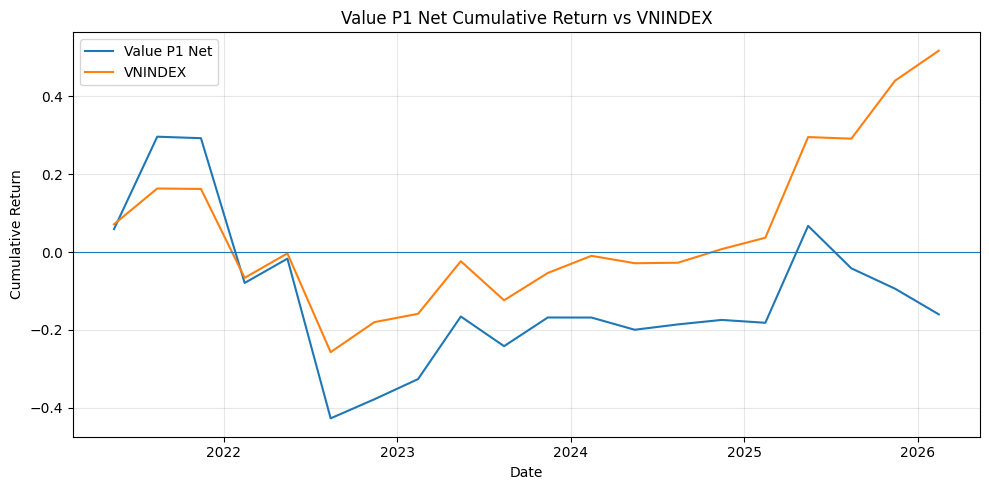

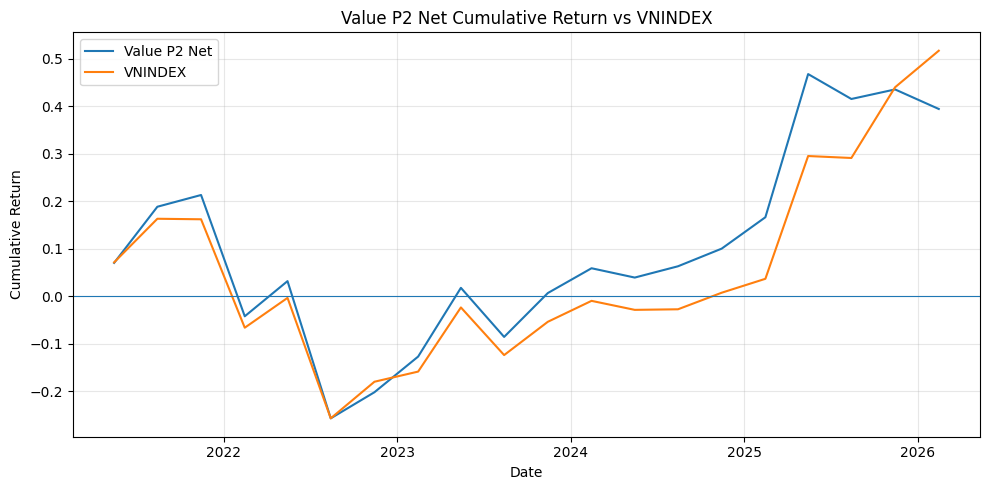

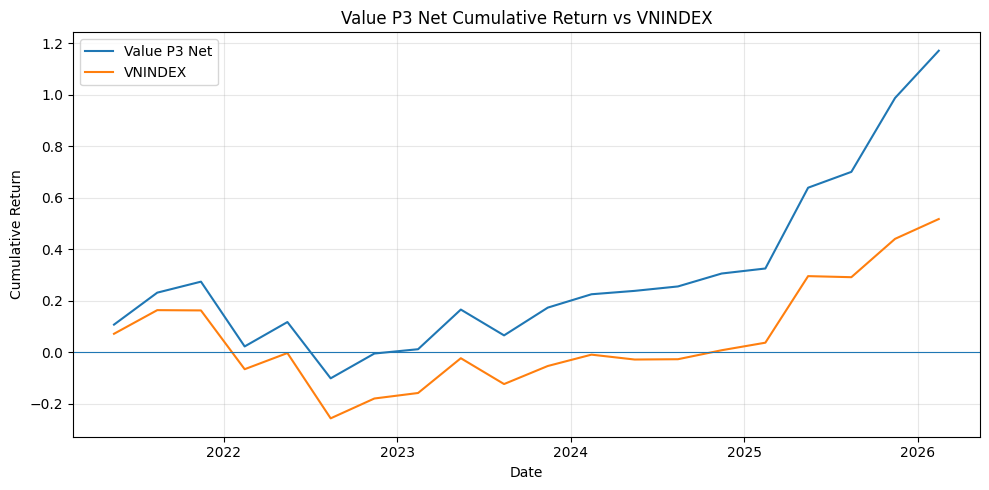

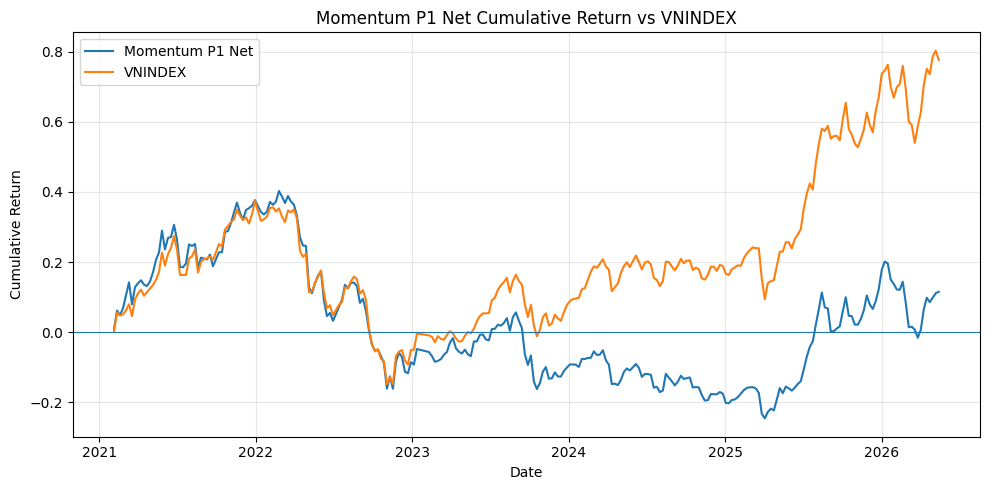

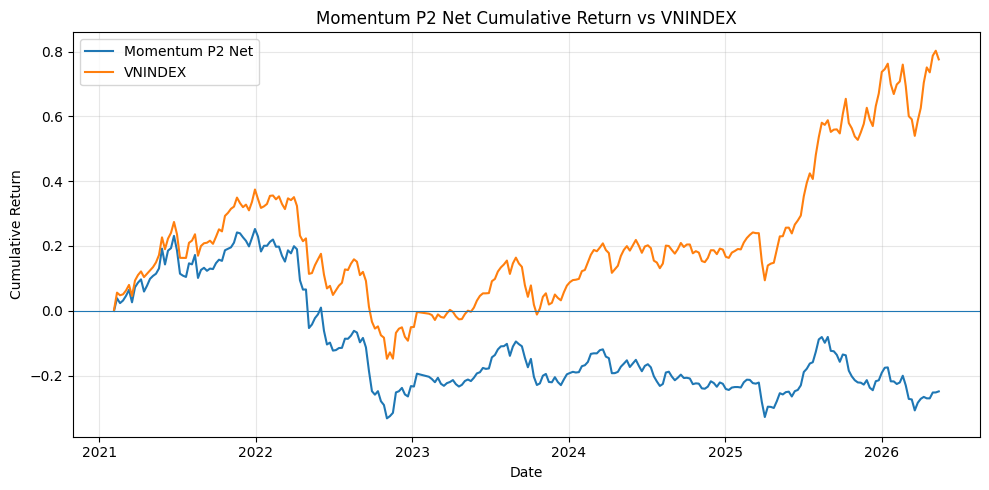

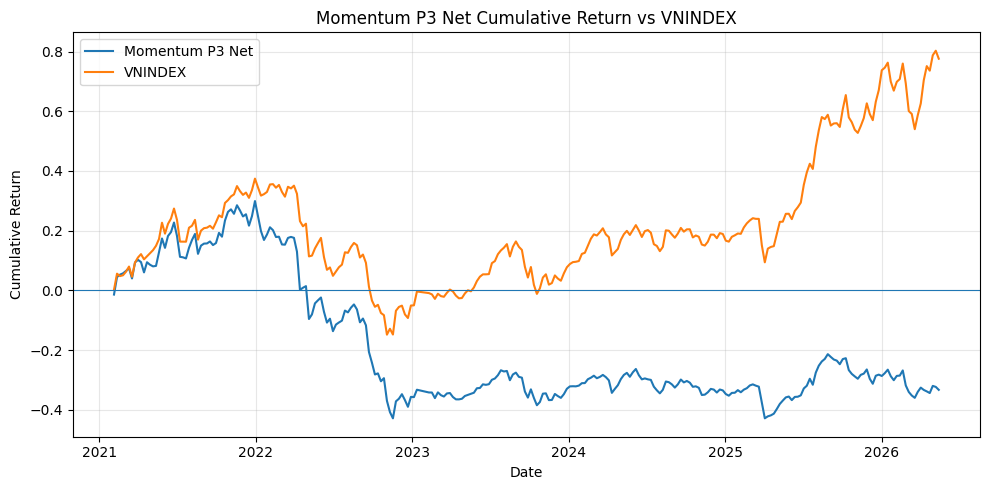

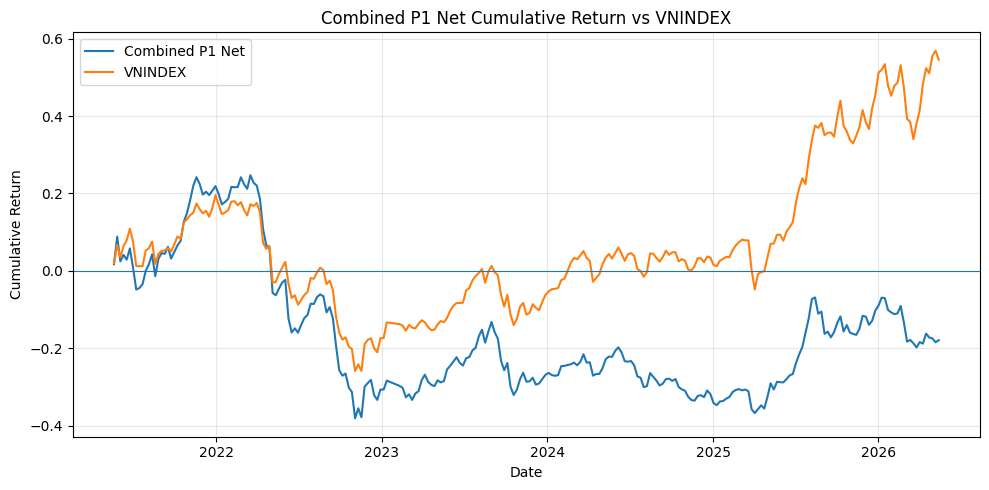

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ VNINDEX comparison files downloaded


In [40]:
# ── BENCHMARK COMPARISON: MODEL PERFORMANCE VS VNINDEX ───────────────

import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
from google.colab import files

print("=" * 90)
print("BENCHMARK COMPARISON: VALUE, MOMENTUM, COMBINED VS VNINDEX")
print("=" * 90)

# --------------------------------------------------------------------
# 1. Upload VNINDEX daily price file
# --------------------------------------------------------------------

print("Upload VNINDEX daily price file...")
uploaded_vnindex = files.upload()

vnindex_filename = list(uploaded_vnindex.keys())[0]
print(f"\n✓ Uploaded VNINDEX file: {vnindex_filename}")

# --------------------------------------------------------------------
# 2. Configure VNINDEX column names
# --------------------------------------------------------------------
# Edit these if your VNINDEX file uses different names.

VN_DATE_COL  = "date"     # or "date", "Date"
VN_CLOSE_COL = "price"    # or "Close", "VNINDEX"
VN_DATE_FORMAT = "%m/%d/%Y"   # change if needed

print("\nVNINDEX configuration:")
print(f"  Date column  : {VN_DATE_COL}")
print(f"  Close column : {VN_CLOSE_COL}")
print(f"  Date format  : {VN_DATE_FORMAT}")

# --------------------------------------------------------------------
# 3. Load and clean VNINDEX data
# --------------------------------------------------------------------

if vnindex_filename.endswith(".xlsx") or vnindex_filename.endswith(".xls"):
    vn_raw = pd.read_excel(io.BytesIO(uploaded_vnindex[vnindex_filename]))
else:
    vn_raw = pd.read_csv(io.BytesIO(uploaded_vnindex[vnindex_filename]))

vn_raw.columns = [str(c).strip() for c in vn_raw.columns]

required_vn_cols = [VN_DATE_COL, VN_CLOSE_COL]
missing_vn_cols = [c for c in required_vn_cols if c not in vn_raw.columns]

if missing_vn_cols:
    raise ValueError(f"VNINDEX file missing required columns: {missing_vn_cols}")

vn_raw = vn_raw.rename(columns={
    VN_DATE_COL: "date",
    VN_CLOSE_COL: "close"
})

vn_raw["date"] = pd.to_datetime(
    vn_raw["date"],
    format=VN_DATE_FORMAT,
    errors="coerce"
)

vn_raw["close"] = pd.to_numeric(vn_raw["close"], errors="coerce")

vn_raw = (
    vn_raw
    .dropna(subset=["date", "close"])
    .query("close > 0")
    .drop_duplicates(subset=["date"], keep="last")
    .sort_values("date")
    .reset_index(drop=True)
)

vnindex_px = vn_raw.set_index("date")["close"].sort_index()

print(f"\nVNINDEX observations : {len(vnindex_px):,}")
print(f"VNINDEX date range   : {vnindex_px.index.min().date()} → {vnindex_px.index.max().date()}")

# --------------------------------------------------------------------
# 4. Helper functions
# --------------------------------------------------------------------

def add_period_end_if_missing(results_df):
    """
    Ensure a result DataFrame has period_end.

    If period_end is missing, infer period_end as the next available date.
    This is mainly for older combo_results versions.
    """

    df = results_df.copy()
    df["date"] = pd.to_datetime(df["date"])

    if "period_end" in df.columns:
        df["period_end"] = pd.to_datetime(df["period_end"])
        return df

    unique_dates = pd.DatetimeIndex(sorted(df["date"].dropna().unique()))
    date_to_next = {
        unique_dates[i]: unique_dates[i + 1]
        for i in range(len(unique_dates) - 1)
    }

    df["period_end"] = df["date"].map(date_to_next)
    df["period_end"] = pd.to_datetime(df["period_end"])

    return df


def compute_vnindex_period_returns(results_df, vnindex_px):
    """
    Compute VNINDEX return from date to period_end for each model period.

    Uses latest available VNINDEX close on or before each date.
    Therefore, non-trading days, weekends, and holidays are handled by ffill.
    """

    df = add_period_end_if_missing(results_df)

    periods = (
        df[["date", "period_end"]]
        .drop_duplicates()
        .dropna()
        .copy()
    )

    periods["date"] = pd.to_datetime(periods["date"])
    periods["period_end"] = pd.to_datetime(periods["period_end"])

    needed_dates = (
        vnindex_px.index
        .union(pd.DatetimeIndex(periods["date"]))
        .union(pd.DatetimeIndex(periods["period_end"]))
        .sort_values()
    )

    vn_ffill = vnindex_px.reindex(needed_dates).ffill()

    rows = []

    for _, r in periods.iterrows():
        start = r["date"]
        end = r["period_end"]

        if start not in vn_ffill.index or end not in vn_ffill.index:
            vn_ret = np.nan
        else:
            start_px = vn_ffill.loc[start]
            end_px = vn_ffill.loc[end]

            if pd.isna(start_px) or pd.isna(end_px) or start_px <= 0:
                vn_ret = np.nan
            else:
                vn_ret = end_px / start_px - 1

        rows.append({
            "date": start,
            "period_end": end,
            "vnindex_ret": vn_ret,
            "vnindex_start_close": vn_ffill.loc[start] if start in vn_ffill.index else np.nan,
            "vnindex_end_close": vn_ffill.loc[end] if end in vn_ffill.index else np.nan,
        })

    return pd.DataFrame(rows)


def attach_vnindex_returns(results_df, vnindex_px):
    """
    Attach VNINDEX holding-period return to a model result table.
    """

    df = add_period_end_if_missing(results_df)

    if "portfolio" not in df.columns:
        df["portfolio"] = "P1"

    vn_period = compute_vnindex_period_returns(df, vnindex_px)

    out = df.merge(
        vn_period,
        on=["date", "period_end"],
        how="left"
    )

    out["active_gross_ret"] = out["gross_ret"] - out["vnindex_ret"]
    out["active_net_ret"] = out["net_ret"] - out["vnindex_ret"]

    return out


def max_drawdown(return_series):
    """
    Compute maximum drawdown from periodic returns.
    """

    r = (
        pd.Series(return_series)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .astype(float)
    )

    if len(r) == 0:
        return np.nan

    wealth = (1 + r).cumprod()
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1

    return drawdown.min()


def ols_alpha_beta(model_ret, benchmark_ret, annual_factor):
    """
    Estimate:
        model_ret_t = alpha + beta * benchmark_ret_t + error_t

    Returns annualized alpha, beta, and alpha t-stat.
    """

    data = pd.concat([
        pd.Series(model_ret).rename("model"),
        pd.Series(benchmark_ret).rename("benchmark")
    ], axis=1).replace([np.inf, -np.inf], np.nan).dropna()

    if len(data) < 4:
        return np.nan, np.nan, np.nan

    y = data["model"].values
    x = data["benchmark"].values

    if np.std(x, ddof=1) == 0:
        return np.nan, np.nan, np.nan

    X = np.column_stack([np.ones(len(x)), x])

    beta_hat = np.linalg.lstsq(X, y, rcond=None)[0]
    resid = y - X @ beta_hat

    dof = len(y) - X.shape[1]

    if dof <= 0:
        return np.nan, np.nan, np.nan

    sigma2 = (resid @ resid) / dof

    try:
        cov_beta = sigma2 * np.linalg.inv(X.T @ X)
        alpha_se = np.sqrt(cov_beta[0, 0])
    except np.linalg.LinAlgError:
        return np.nan, np.nan, np.nan

    alpha_periodic = beta_hat[0]
    beta = beta_hat[1]

    alpha_annual = alpha_periodic * annual_factor
    alpha_t = alpha_periodic / alpha_se if alpha_se > 0 else np.nan

    return alpha_annual, beta, alpha_t


def performance_vs_vnindex(df, model_name, annual_factor):
    """
    Build performance summary vs VNINDEX by portfolio.
    """

    rows = []

    for pf, g in df.groupby("portfolio"):
        g = g.sort_values("date").copy()

        r_net = g["net_ret"].replace([np.inf, -np.inf], np.nan).dropna()
        r_gross = g["gross_ret"].replace([np.inf, -np.inf], np.nan).dropna()
        b = g["vnindex_ret"].replace([np.inf, -np.inf], np.nan)

        common = g[["net_ret", "gross_ret", "vnindex_ret"]].replace(
            [np.inf, -np.inf],
            np.nan
        ).dropna()

        if len(common) == 0:
            continue

        net = common["net_ret"]
        gross = common["gross_ret"]
        bench = common["vnindex_ret"]

        active = net - bench

        ann_net = net.mean() * annual_factor
        ann_gross = gross.mean() * annual_factor
        ann_bench = bench.mean() * annual_factor
        ann_active = active.mean() * annual_factor

        cagr_net = (1 + net).prod() ** (annual_factor / len(net)) - 1
        cagr_bench = (1 + bench).prod() ** (annual_factor / len(bench)) - 1

        ann_vol = net.std(ddof=1) * np.sqrt(annual_factor)
        ann_bench_vol = bench.std(ddof=1) * np.sqrt(annual_factor)
        tracking_error = active.std(ddof=1) * np.sqrt(annual_factor)

        sharpe = ann_net / ann_vol if ann_vol > 0 else np.nan
        info_ratio = ann_active / tracking_error if tracking_error > 0 else np.nan

        alpha, beta, alpha_t = ols_alpha_beta(
            model_ret=net,
            benchmark_ret=bench,
            annual_factor=annual_factor
        )

        rows.append({
            "model": model_name,
            "portfolio": pf,
            "n_periods": len(common),
            "ann_gross_return": ann_gross,
            "ann_net_return": ann_net,
            "vnindex_ann_return": ann_bench,
            "ann_active_return": ann_active,
            "model_cagr": cagr_net,
            "vnindex_cagr": cagr_bench,
            "ann_volatility": ann_vol,
            "vnindex_ann_volatility": ann_bench_vol,
            "tracking_error": tracking_error,
            "sharpe_zero_rf": sharpe,
            "information_ratio": info_ratio,
            "alpha_vs_vnindex": alpha,
            "beta_vs_vnindex": beta,
            "alpha_t_stat": alpha_t,
            "max_drawdown": max_drawdown(net),
            "vnindex_max_drawdown": max_drawdown(bench),
            "win_rate_vs_vnindex": (active > 0).mean(),
            "avg_turnover": g["turnover"].mean() if "turnover" in g.columns else np.nan,
            "ann_fee_drag": g["fee_drag"].mean() * annual_factor if "fee_drag" in g.columns else np.nan,
        })

    return pd.DataFrame(rows)


def cumulative_comparison_df(df, model_name):
    """
    Build cumulative net return and VNINDEX cumulative return series.
    """

    pieces = []

    for pf, g in df.groupby("portfolio"):
        g = (
            g
            .sort_values("date")
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=["net_ret", "vnindex_ret"])
            .copy()
        )

        if g.empty:
            continue

        g["model_cum_net"] = (1 + g["net_ret"]).cumprod() - 1
        g["vnindex_cum"] = (1 + g["vnindex_ret"]).cumprod() - 1
        g["active_cum"] = (1 + (g["net_ret"] - g["vnindex_ret"])).cumprod() - 1

        g["model"] = model_name
        g["portfolio"] = pf

        pieces.append(
            g[[
                "model", "portfolio", "date", "period_end",
                "net_ret", "vnindex_ret",
                "model_cum_net", "vnindex_cum", "active_cum"
            ]]
        )

    if pieces:
        return pd.concat(pieces, ignore_index=True)

    return pd.DataFrame()


# --------------------------------------------------------------------
# 5. Attach VNINDEX returns to each model result table
# --------------------------------------------------------------------

value_vs_vnindex = attach_vnindex_returns(
    value_quarterly_results,
    vnindex_px
)

momentum_vs_vnindex = attach_vnindex_returns(
    mom_mcap_results,
    vnindex_px
)

# Combined model: expected to be P1-focused.
combo_for_benchmark = combo_results.copy()

if "portfolio" not in combo_for_benchmark.columns:
    combo_for_benchmark["portfolio"] = "P1"

combo_vs_vnindex = attach_vnindex_returns(
    combo_for_benchmark,
    vnindex_px
)

print("\n✓ VNINDEX returns attached to model result tables")

# --------------------------------------------------------------------
# 6. Build summary tables
# --------------------------------------------------------------------

value_perf = performance_vs_vnindex(
    value_vs_vnindex,
    model_name="Value",
    annual_factor=4
)

momentum_perf = performance_vs_vnindex(
    momentum_vs_vnindex,
    model_name="Momentum",
    annual_factor=52
)

combo_perf = performance_vs_vnindex(
    combo_vs_vnindex,
    model_name="Combined",
    annual_factor=52
)

performance_vs_vnindex_summary = pd.concat(
    [value_perf, momentum_perf, combo_perf],
    ignore_index=True
)

print("\nPERFORMANCE VS VNINDEX")
display(
    performance_vs_vnindex_summary.style.format({
        "ann_gross_return": "{:.2%}",
        "ann_net_return": "{:.2%}",
        "vnindex_ann_return": "{:.2%}",
        "ann_active_return": "{:.2%}",
        "model_cagr": "{:.2%}",
        "vnindex_cagr": "{:.2%}",
        "ann_volatility": "{:.2%}",
        "vnindex_ann_volatility": "{:.2%}",
        "tracking_error": "{:.2%}",
        "sharpe_zero_rf": "{:.2f}",
        "information_ratio": "{:.2f}",
        "alpha_vs_vnindex": "{:.2%}",
        "beta_vs_vnindex": "{:.2f}",
        "alpha_t_stat": "{:.2f}",
        "max_drawdown": "{:.2%}",
        "vnindex_max_drawdown": "{:.2%}",
        "win_rate_vs_vnindex": "{:.1%}",
        "avg_turnover": "{:.1%}",
        "ann_fee_drag": "{:.2%}",
    })
)

# --------------------------------------------------------------------
# 7. Build cumulative return data
# --------------------------------------------------------------------

cum_value = cumulative_comparison_df(value_vs_vnindex, "Value")
cum_momentum = cumulative_comparison_df(momentum_vs_vnindex, "Momentum")
cum_combo = cumulative_comparison_df(combo_vs_vnindex, "Combined")

cumulative_vs_vnindex = pd.concat(
    [cum_value, cum_momentum, cum_combo],
    ignore_index=True
)

# --------------------------------------------------------------------
# 8. Plot cumulative net return vs VNINDEX
# --------------------------------------------------------------------

for model_name in cumulative_vs_vnindex["model"].dropna().unique():

    model_df = cumulative_vs_vnindex[
        cumulative_vs_vnindex["model"] == model_name
    ]

    for pf in model_df["portfolio"].dropna().unique():

        plot_df = model_df[
            model_df["portfolio"] == pf
        ].sort_values("date")

        if plot_df.empty:
            continue

        plt.figure(figsize=(10, 5))
        plt.plot(plot_df["date"], plot_df["model_cum_net"], label=f"{model_name} {pf} Net")
        plt.plot(plot_df["date"], plot_df["vnindex_cum"], label="VNINDEX")
        plt.axhline(0, linewidth=0.8)
        plt.title(f"{model_name} {pf} Net Cumulative Return vs VNINDEX")
        plt.xlabel("Date")
        plt.ylabel("Cumulative Return")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        chart_name = f"cum_return_{model_name.lower()}_{pf.lower()}_vs_vnindex.png"
        plt.savefig(chart_name, dpi=150)
        plt.show()

# --------------------------------------------------------------------
# 9. Save outputs
# --------------------------------------------------------------------

value_vs_vnindex.to_csv("value_model_vs_vnindex_period_returns.csv", index=False)
momentum_vs_vnindex.to_csv("momentum_model_vs_vnindex_period_returns.csv", index=False)
combo_vs_vnindex.to_csv("combined_model_vs_vnindex_period_returns.csv", index=False)

performance_vs_vnindex_summary.to_csv(
    "performance_vs_vnindex_summary.csv",
    index=False
)

cumulative_vs_vnindex.to_csv(
    "cumulative_returns_vs_vnindex.csv",
    index=False
)

excel_file = "performance_vs_vnindex_report.xlsx"

with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:
    performance_vs_vnindex_summary.to_excel(
        writer,
        sheet_name="Summary",
        index=False
    )

    value_vs_vnindex.to_excel(
        writer,
        sheet_name="Value Period Returns",
        index=False
    )

    momentum_vs_vnindex.to_excel(
        writer,
        sheet_name="Momentum Period Returns",
        index=False
    )

    combo_vs_vnindex.to_excel(
        writer,
        sheet_name="Combined Period Returns",
        index=False
    )

    cumulative_vs_vnindex.to_excel(
        writer,
        sheet_name="Cumulative Returns",
        index=False
    )

files.download("performance_vs_vnindex_summary.csv")
files.download("cumulative_returns_vs_vnindex.csv")
files.download("value_model_vs_vnindex_period_returns.csv")
files.download("momentum_model_vs_vnindex_period_returns.csv")
files.download("combined_model_vs_vnindex_period_returns.csv")
files.download(excel_file)

print("\n✓ VNINDEX comparison files downloaded")